# No 2

# Import Library

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Konfigurasi Awal & Global
warnings.filterwarnings('ignore')
np.random.seed(42)

# 2. Statistik & Analisis Time Series
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

# 3. Machine Learning Preprocessing & Metrics
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 4. TensorFlow & Keras Core
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
import tensorflow.keras.backend as K

# 5. Keras Functional API & Layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, GRU, Dense, Dropout, Bidirectional, 
    BatchNormalization, Softmax, Multiply, Lambda, Activation
)

# 6. Keras Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 7. Konfigurasi Visualisasi (Matplotlib/Seaborn)
tf.random.set_seed(42)
plt.rcParams.update({
    'figure.dpi' : 120,
    'axes.spines.top' : False,
    'axes.spines.right' : False,
    'font.size': 10,
})

# check gpu

In [2]:

print("Num GPUs Available :  ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available :   1


# Load Datasets

In [3]:
def load_btc_data() : 

        df = yf.download('BTC-USD', start='2021-06-07', end='2026-05-07', interval='1d')
        df.columns = df.columns.get_level_values(0)
        df = df[['Open','High','Low','Close','Volume']].dropna()
        df.index.name = 'Date'
        return df, 'Yahoo Finance'
 

df_raw, DATA_SOURCE = load_btc_data()

print(f'\nSource      :  {DATA_SOURCE}')
print(f'Shape       :  {df_raw.shape}')
print(f'Date range  :  {df_raw.index[0].date()} to {df_raw.index[-1].date()}')
print(f'Price range :  ${df_raw.Close.min():,.0f} to ${df_raw.Close.max():,.0f}')
df_raw.head()
df_raw.to_csv('btc_daily.csv', index=True)

[*********************100%***********************]  1 of 1 completed


Source      :  Yahoo Finance
Shape       :  (1795, 5)
Date range  :  2021-06-07 to 2026-05-06
Price range :  $15,787 to $124,753


In [4]:
df_raw.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2021-06-07,35835.265625,36790.570312,33480.640625,33560.707031,33683936663
2021-06-08,33589.519531,34017.386719,31114.443359,33472.632812,49902050442
2021-06-09,33416.976562,37537.371094,32475.865234,37345.121094,53972919008
2021-06-10,37389.515625,38334.324219,35847.593750,36702.597656,43576032854
2021-06-11,36697.031250,37608.695312,36044.449219,37334.398438,38699736985


In [5]:
df_raw.tail()

Price,Open,High,Low,Close,Volume
Date,,,,,
2026-05-02,78177.750000,79119.789062,78031.960938,78657.250000,16761531851
2026-05-03,78656.726562,79402.359375,78073.078125,78538.226562,20544392639
2026-05-04,78540.289062,80742.359375,78217.960938,79827.906250,54325085296
2026-05-05,79823.531250,81751.453125,79787.578125,80927.054688,39700107376
2026-05-06,80930.734375,82792.210938,80751.023438,81427.531250,41751540000


In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2021-06-07 to 2026-05-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1795 non-null   float64
 1   High    1795 non-null   float64
 2   Low     1795 non-null   float64
 3   Close   1795 non-null   float64
 4   Volume  1795 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 84.1 KB


# EDA

## Raw Data Visualization using OHLCV

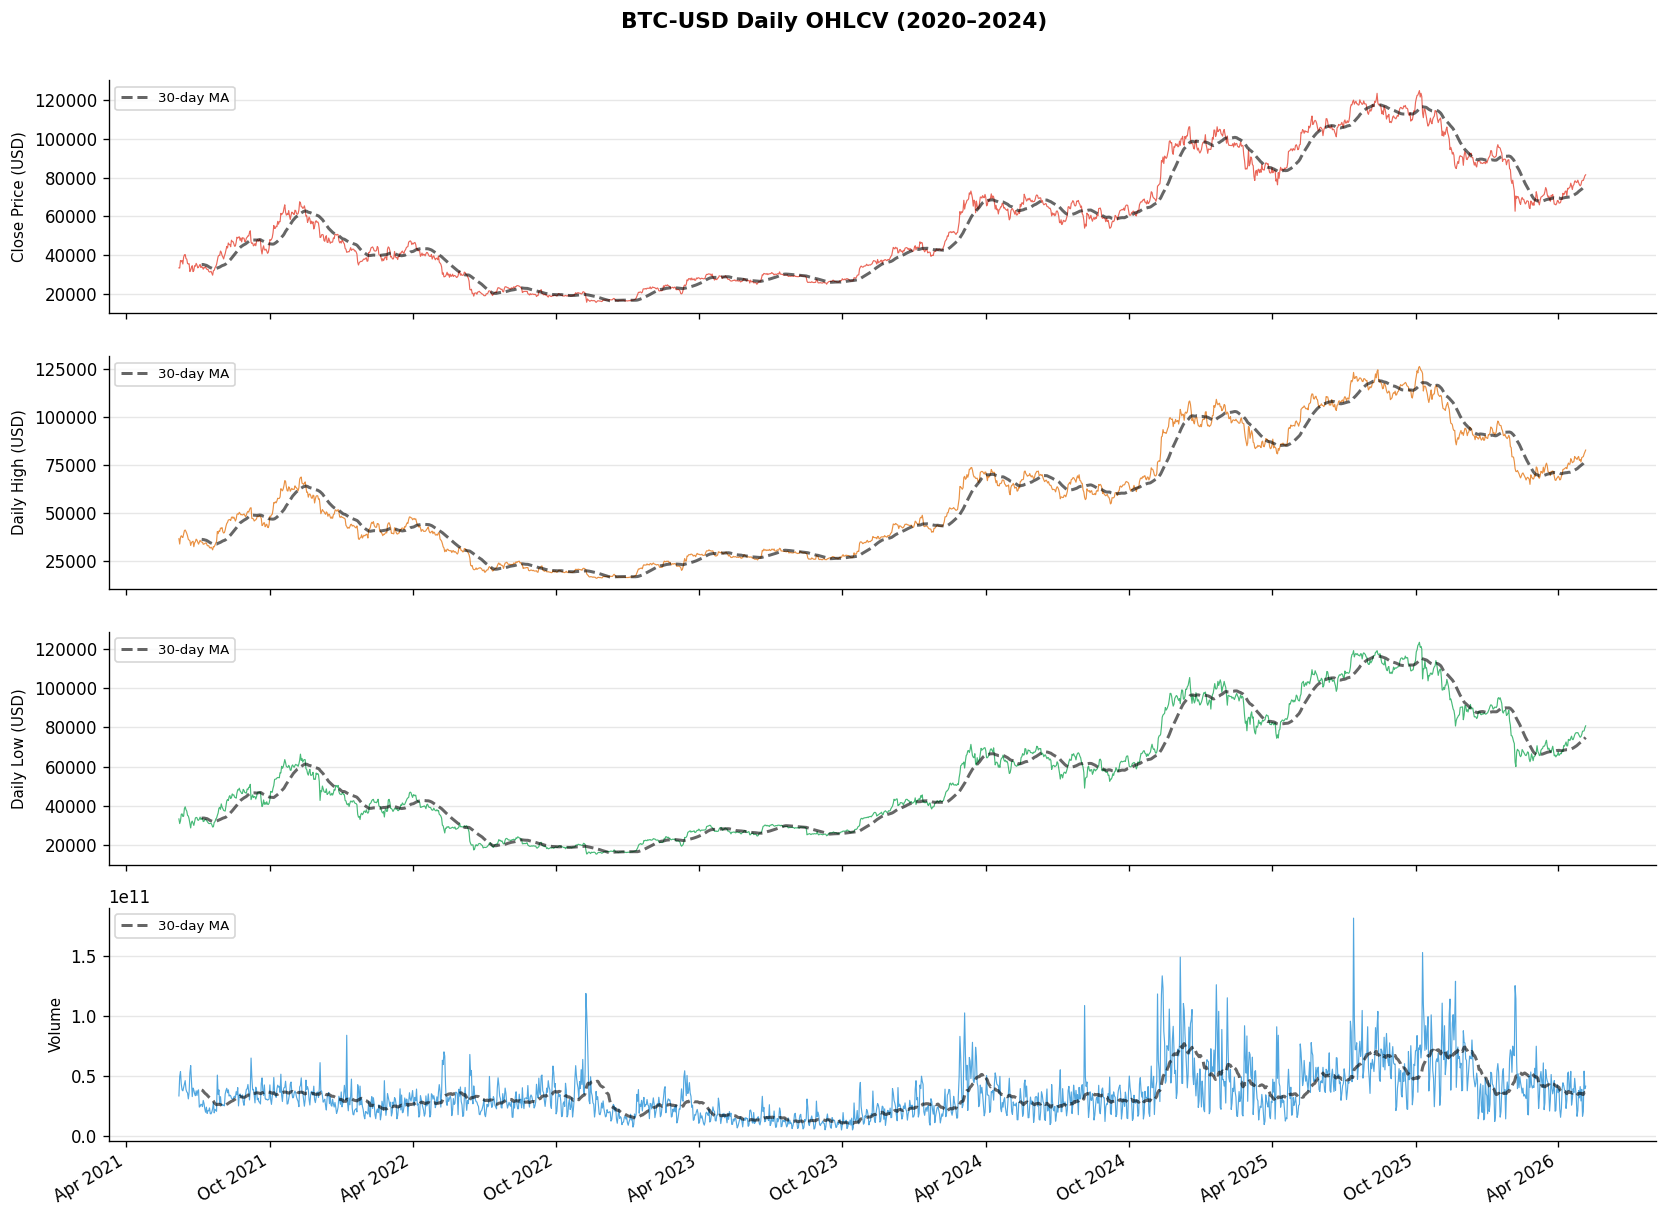

In [7]:
def show_raw_visualization(data):

    cols   = ['Close', 'High', 'Low', 'Volume']
    labels = ['Close Price (USD)', 'Daily High (USD)', 'Daily Low (USD)', 'Volume']
    colors = ['#E74C3C', '#E67E22', '#27AE60', '#3498DB']

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    for ax, col, label, color in zip(axes, cols, labels, colors):
        ax.plot(data.index, data[col], color=color, linewidth=0.7, alpha=0.85)
        ax.plot(data.index, data[col].rolling(30).mean(), color='black',
                linewidth=1.8, linestyle='--', alpha=0.6, label='30-day MA')
        ax.set_ylabel(label, fontsize=9)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=30, ha='right')
    fig.suptitle('BTC-USD Daily OHLCV (2020–2024)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('eda_raw.png', bbox_inches='tight')
    plt.show()

show_raw_visualization(df_raw)



#### Harga Bitcoin terlihat mengalami kenaikan signifikan (tren bullish) yang dimulai pada awal tahun 2024 hingga mencapai puncak di atas 100.000 USD.

#### Panel paling bawah menunjukkan volume perdagangan yang sangat fluktuatif dengan lonjakan besar yang biasanya menyertai perubahan harga yang drastis.

#### Secara keseluruhan, grafik ini membantu memantau volatilitas pasar dan mengidentifikasi momentum harga melalui perbandingan antara harga harian dan garis rata-ratanya.

## Visualizing STL 

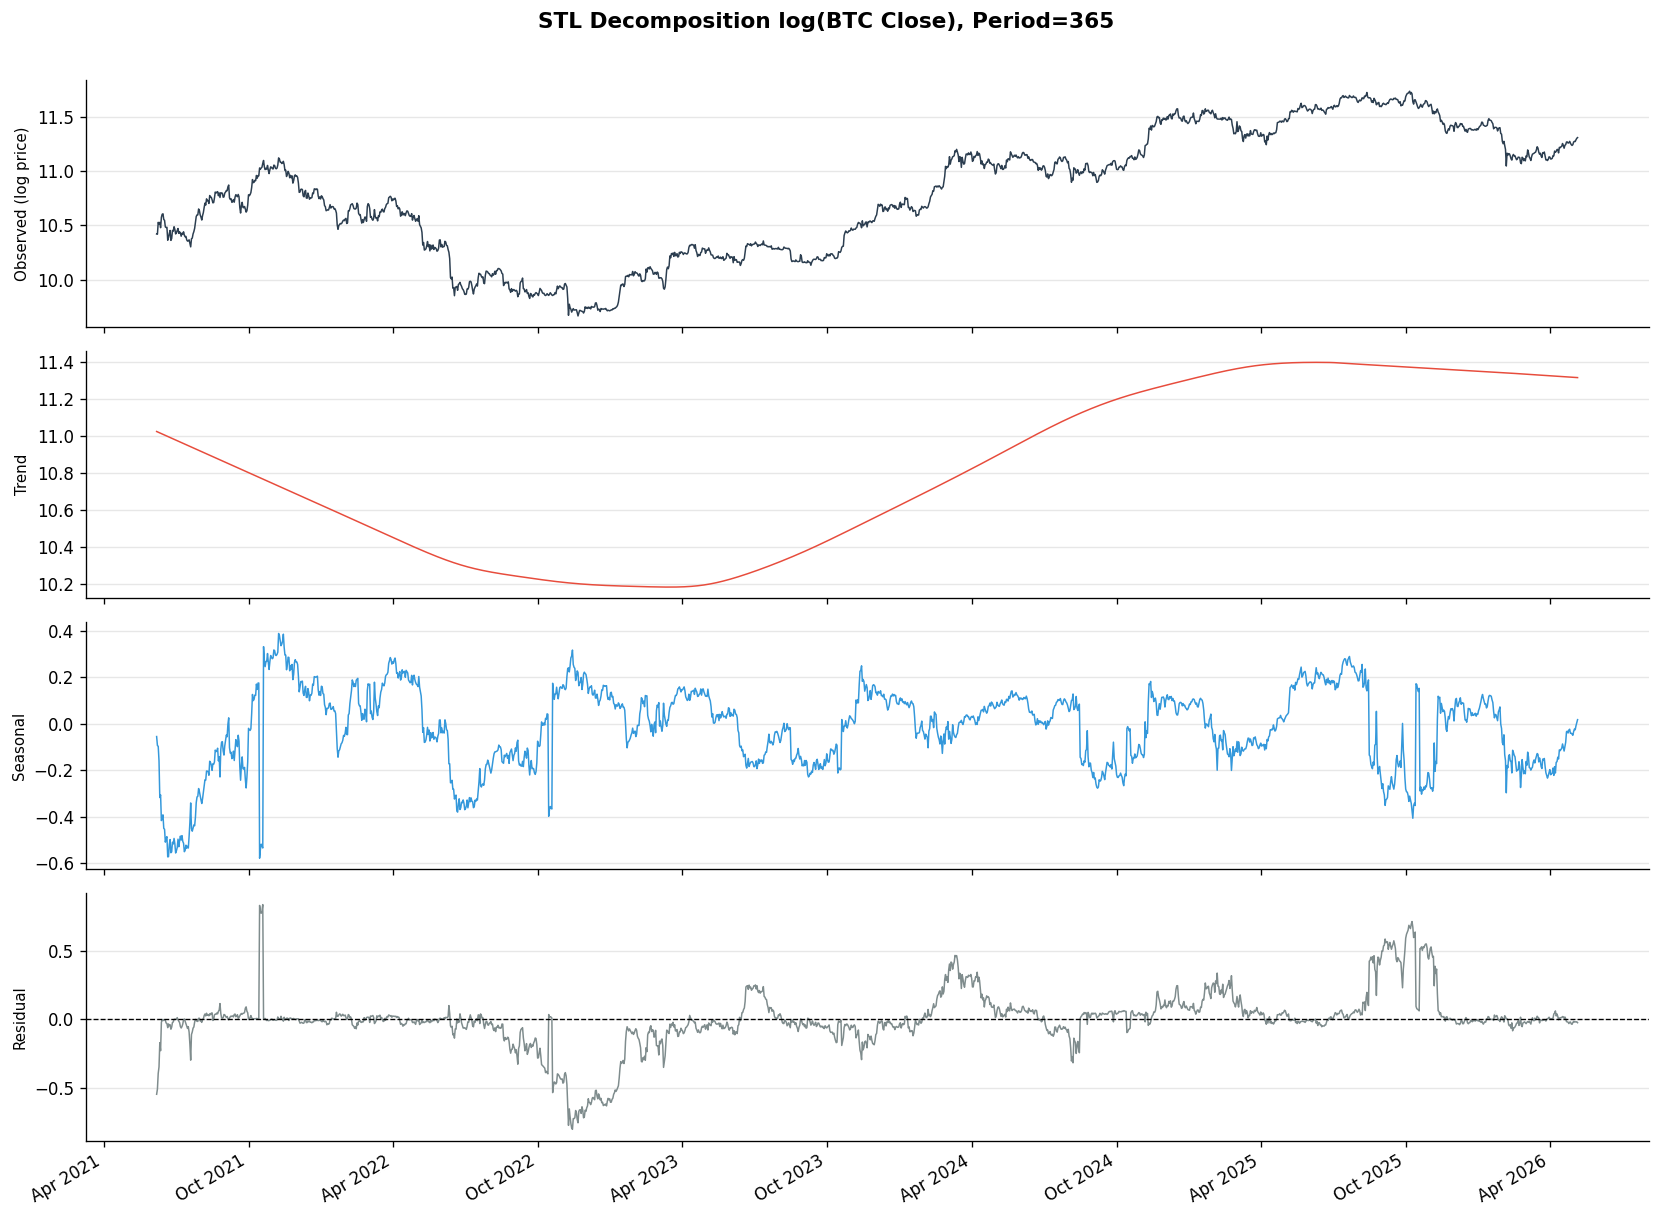

Strength of Trend      :  0.1348
Strength of Seasonality :  0.8757


In [8]:
log_close = np.log(df_raw['Close'])
stl    = STL(log_close, period=365, seasonal=13, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, (series, label, color) in zip(axes, [
    (log_close,       'Observed (log price)', '#2C3E50'),
    (result.trend,    'Trend',                '#E74C3C'),
    (result.seasonal, 'Seasonal',             '#3498DB'),
    (result.resid,    'Residual',             '#7F8C8D'),
]):
    ax.plot(df_raw.index, series, color=color, linewidth=0.9)
    if label == 'Residual':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
fig.suptitle('STL Decomposition log(BTC Close), Period=365',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_stl.png', bbox_inches='tight')
plt.show()

var_r = np.var(result.resid)
fs = max(0, 1 - var_r / np.var(result.seasonal + result.resid))
ft = max(0, 1 - var_r / np.var(result.trend    + result.resid))
print(f'Strength of Trend      :  {fs:.4f}')
print(f'Strength of Seasonality :  {ft:.4f}')

#### Observed (Log Price) untuk  Merupakan representasi data historis harga Bitcoin dalam skala logaritma untuk menstabilkan varians dan memastikan fluktuasi harga di berbagai level (saat harga rendah vs tinggi) dapat dianalisis secara proporsional.

#### Trend untuk  Menunjukkan komponen sekuler atau arah pergerakan harga jangka panjang yang telah dibersihkan dari noise; terlihat fase bearish hingga awal 2023 yang kemudian diikuti oleh fase bullish yang kuat hingga 2025.

#### Seasonal untuk  Mengekstraksi pola berulang dalam periode 365 hari. Namun, fluktuasi yang tidak beraturan mengonfirmasi bahwa aset kripto memiliki pola musiman yang lemah dibandingkan data deret waktu tradisional.

#### Residual untuk  Merupakan komponen noise atau anomali yang tidak tertangkap oleh tren maupun musiman, mencerminkan volatilitas mendadak akibat peristiwa eksternal (market shocks/black swan/ news effect) yang signifikan di akhir 2021 dan 2025.

#### Hasil STL decomposition menunjukkan Strength of Trend sebesar 0.8757, mengindikasikan bahwa komponen trend mendominasi variasi data BTC. Hal ini konsisten dengan karakteristik BTC sebagai aset yang mengalami siklus bull dan bear market multi-tahun.

#### Sementara itu, Strength of Seasonality yang rendah (0.1348) menunjukkan bahwa BTC tidak memiliki pola musiman yang kuat, pergerakan harga lebih dipengaruhi oleh faktor eksternal seperti regulasi, halving event, dan sentimen pasar daripada pola kalender.

#### Dominasi komponen trend yang kuat, dikombinasikan dengan sifat data yang sequential dan non-linear, memvalidasi penggunaan arsitektur Stacked GRU yang mampu menangkap dependensi jangka panjang antar timestep melalui mekanisme menangkap sesuatu yang tidak dapat dilakukan oleh model regresi linear konvensional.

## Monthly and Weekly Seasonality Profiles

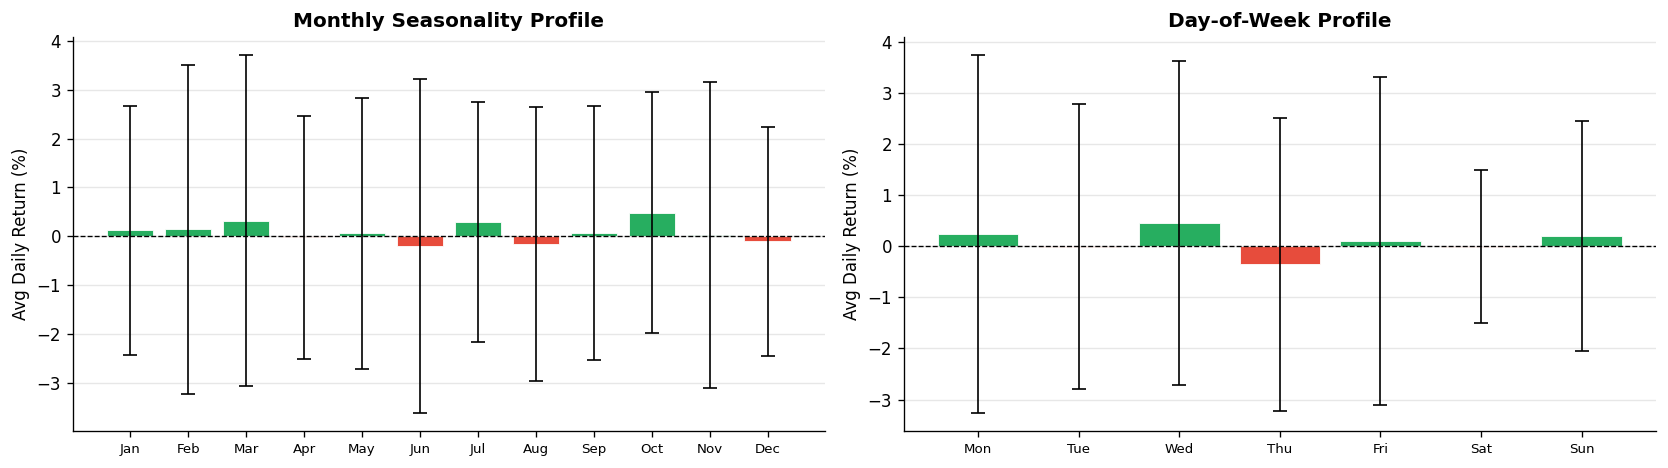

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ret = df_raw['Close'].pct_change() * 100

m_ret = ret.groupby(df_raw.index.month).agg(['mean','std'])
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(range(1,13), m_ret['mean'],
            color=['#E74C3C' if v<0 else '#27AE60' for v in m_ret['mean']],
            edgecolor='white', linewidth=0.5)
axes[0].errorbar(range(1,13), m_ret['mean'], yerr=m_ret['std'],
                 fmt='none', color='black', capsize=4, linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(months, fontsize=8)
axes[0].set_ylabel('Avg Daily Return (%)')
axes[0].set_title('Monthly Seasonality Profile', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

d_ret = ret.groupby(df_raw.index.dayofweek).agg(['mean','std'])
days  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(range(7), d_ret['mean'],
            color=['#E74C3C' if v<0 else '#27AE60' for v in d_ret['mean']],
            edgecolor='white', linewidth=0.5)
axes[1].errorbar(range(7), d_ret['mean'], yerr=d_ret['std'],
                 fmt='none', color='black', capsize=4, linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(days, fontsize=8)
axes[1].set_ylabel('Avg Daily Return (%)')
axes[1].set_title('Day-of-Week Profile', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_seasonality.png', bbox_inches='tight')
plt.show()

#### Grafik ini menunjukkan bahwa meskipun terdapat variasi average daily return pada bulan atau hari tertentu, tingginya volatilitas (ditunjukkan oleh error bars yang lebar) mengonfirmasi bahwa pola kalender tidak memiliki konsistensi yang signifikan sebagai prediktor harga.

#### Rendahnya nilai Strength of Seasonality (0.1348) secara visual terbukti dari rata-rata return hasil yang relatif kecil dibandingkan dengan standar deviasi harian, sehingga pergerakan harga lebih didominasi oleh komponen tren dan residual dibandingkan siklus musiman.

## Correlation Matrix & Stationarity Test (ADF)

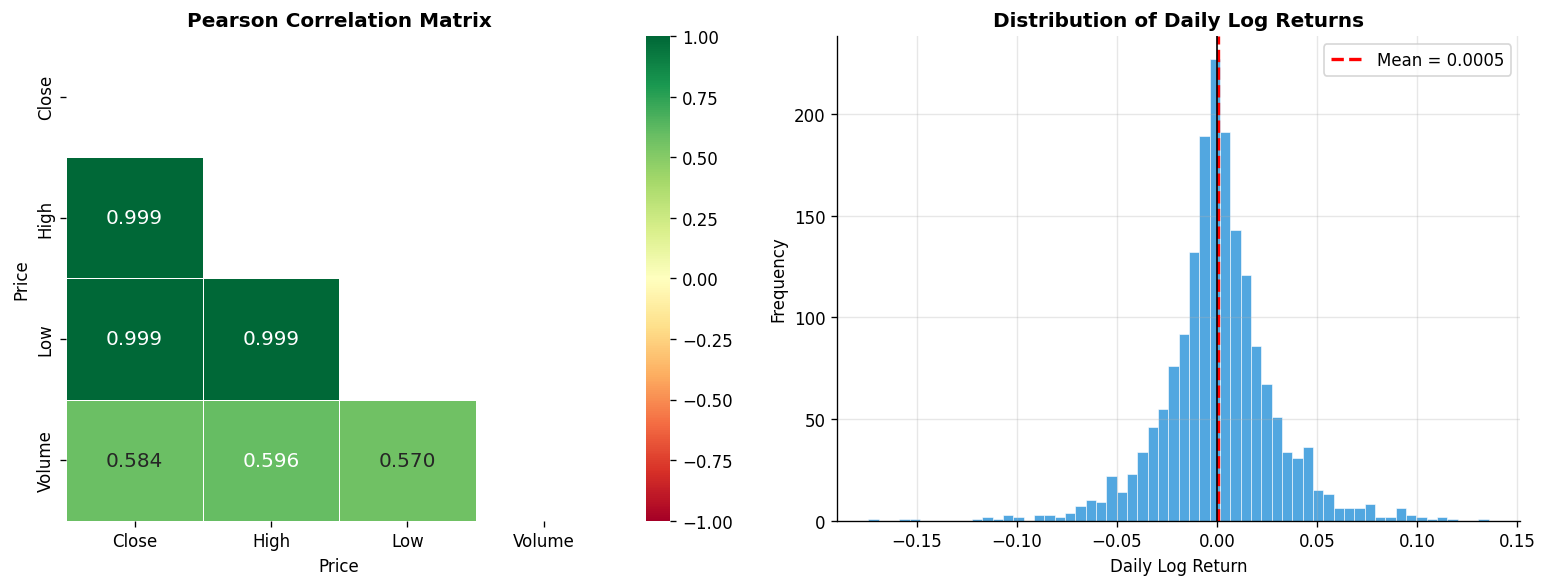

ADF Stationarity Test: 
  [Raw Close Price   ]:  p=0.732233  maka Non-Stationary sehingga butuh transformation
  [Log Returns       ]:  p=0.000000  maka Stationary 


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

corr = df_raw[['Close','High','Low','Volume']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size':12}, ax=axes[0])
axes[0].set_title('Pearson Correlation Matrix', fontweight='bold')

log_ret = np.log(df_raw['Close'] / df_raw['Close'].shift(1)).dropna()
axes[1].hist(log_ret, bins=60, color='#3498DB', edgecolor='white', linewidth=0.4, alpha=0.85)
axes[1].axvline(log_ret.mean(), color='red', linewidth=2, linestyle='--',
                label=f'Mean = {log_ret.mean():.4f}')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Daily Log Return'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Daily Log Returns', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_corr.png', bbox_inches='tight')
plt.show()

print('ADF Stationarity Test: ')
for name, series in [('Raw Close Price', df_raw['Close']), ('Log Returns', log_ret)]:
    stat, p, *_ = adfuller(series)
    tag = 'Stationary ' if p < 0.05 else 'Non-Stationary sehingga butuh transformation'
    print(f'  [{name:<18}]:  p={p:.6f}  maka {tag}')

#### Korelasi dan Multikolinieritas untuk  Matriks korelasi Pearson menunjukkan hubungan yang hampir sempurna ($r = 0,999$) antara variabel Close, High, dan Low, yang mengindikasikan adanya multikolinieritas struktural karena ketiga variabel tersebut mengikuti tren harga yang sama.

#### Karakteristik Distribusi Log Return untuk  Distribusi daily log returns berpusat di sekitar nilai rata-rata 0,0005 dengan bentuk yang menyerupai distribusi normal namun memiliki ekor yang lebar (fat-tails), yang mencerminkan risiko volatilitas ekstrem yang umum terjadi pada pasar kripto.

#### Uji Stasioneritas ADFuntuk  Hasil uji Augmented Dickey-Fuller (ADF) menunjukkan bahwa harga closing raw bersifat non-stasioner ($p = 0,7327$), sedangkan transformasi menjadi log returns berhasil menghasilkan data yang stasioner ($p = 0,0000$), sehingga data tersebut valid untuk digunakan dalam pemodelan time series.

## EDA Summary

### Dominasi Tren
#### Pergerakan harga BTC hampir sepenuhnya digerakkan oleh siklus jangka panjang (skor 0.8757) dibandingkan pola musiman kalender yang sangat lemah.

### Stasioneritas Data
#### Transformasi ke log returns berhasil mengubah data dari non-stationary menjadi stationary ($p=0.00$), sehingga valid dan siap digunakan.

### Multikolinieritas Ekstrem
#### Korelasi hampir sempurna ($r=0.999$) antara harga High, Low, dan Close menunjukkan redundansi fitur yang berisiko menyebabkan overfitting jika semuanya digunakan mentah-mentah.

### Volatilitas Tinggi (Fat-Tails)
#### Distribusi log returns yang berpusat di 0.0005 namun memiliki ekor lebar mengonfirmasi adanya risiko pergerakan harga ekstrem yang sering terjadi di pasar kripto.

### Ketidakpastian Kalender
#### Error bars yang sangat lebar pada profit bulanan dan harian menunjukkan bahwa pola tanggal bukan merupakan prediktor harga yang konsisten atau reliabel.

# Data Preprocessing


## Feature Engineering

| Feature | Formula | Type |
|---------|---------|------|
| `log_return` | $\ln(C_t/C_{t-1})$ | Target |
| `rsi_14` | Wilder RSI, period=14 | Overbought/oversold (0–100) |
| `bb_pos` | $(C_t - BB_{lower}) / (BB_{upper} - BB_{lower})$ | Price position in band (0–1) |
| `norm_range` | $(H_t - L_t) / C_t$ | Normalized daily volatility |
| `lag1`, `lag2`, `lag3` | $r_{t-1}, r_{t-2}, r_{t-3}$ | Short-term momentum lags |
| `vol_pct` | $\Delta V_t / V_{t-1}$ | Volume change % |



### log_return
#### Menghitung selisih logaritma antara harga hari ini ($C_t$) dengan harga kemarin ($C_{t-1}$). Tujuan untuk  Mengubah perubahan harga menjadi persentase yang stabil secara statistik. Ini digunakan sebagai Target (apa yang ingin ditebak) sekaligus sinyal histori.

### rsi_14 (Relative Strength Index) 
#### Mengukur kecepatan dan besarnya perubahan harga dalam periode 14 hari. Tujuan untuk  Menentukan kondisi pasar apakah sudah Overbought (terlalu mahal/jenuh beli) atau Oversold (terlalu murah/jenuh jual) dalam skala 0–100.

### bb_pos (Bollinger Band Position) 
#### Menghitung di mana posisi harga penutupan saat ini relatif terhadap rentang Upper dan Lower Bollinger Bands. Tujuan untuk  Menormalisasi posisi harga ke dalam skala 0–1. Angka 0 berarti harga di garis bawah, dan 1 berarti di garis atas, terlepas dari apakah harga Bitcoin sedang $10k atau $100k.4. norm_range 

### (Normalized Daily Volatility) 
#### Menghitung selisih harga tertinggi ($H_t$) dan terendah ($L_t$) hari ini, kemudian dibagi dengan harga penutupan ($C_t$). Tujuan untuk  Mengukur Volatilitas harian secara murni. Dengan membaginya dengan $C_t$, fitur ini menjadi stasioner dan tidak lagi memiliki korelasi ekstrem (multikolinieritas) dengan harga absolut.

### lag1, lag2, lag3 
#### Mengambil nilai log_return dari 1, 2, dan 3 hari ke belakang ($r_{t-1}, r_{t-2}, r_{t-3}$). Tujuan untuk  Memberikan model "ingatan" tentang momentum jangka pendek. Model bisa melihat apakah dalam 3 hari terakhir trennya sedang menguat atau melemah.

### vol_pct (Volume Change Percentage)
#### Menghitung persentase perubahan volume perdagangan hari ini dibanding kemarin ($\Delta V_t / V_{t-1}$). Tujuan untuk  Melihat lonjakan aktivitas pasar. Lonjakan volume seringkali menjadi konfirmasi bahwa sebuah pergerakan harga (naik/turun) didukung oleh banyak pelaku pasar.

###

In [13]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - (100 / (1 + gain / loss.replace(0, np.nan)))


df = df_raw.copy()

In [14]:


df['log_return']  = np.log(df['Close'] / df['Close'].shift(1))
df['rsi_14']      = compute_rsi(df['Close'], 14)

bb_mid            = df['Close'].rolling(20).mean()
bb_std            = df['Close'].rolling(20).std()
df['bb_pos']      = (df['Close'] - (bb_mid - 2*bb_std)) / (4 * bb_std.replace(0, np.nan))
df['norm_range']  = (df['High'] - df['Low']) / df['Close']

df['lag1']        = df['log_return'].shift(1)
df['lag2']        = df['log_return'].shift(2)
df['lag3']        = df['log_return'].shift(3)
df['vol_pct']     = df['Volume'].pct_change().clip(-3, 3)
df = df.dropna()

FEATURES  = ['log_return', 'rsi_14', 'bb_pos', 'norm_range', 'lag1', 'lag2', 'lag3', 'vol_pct']
TARGET    = 'log_return'    
TARGET_IDX = 0              

print(f'Features   : {FEATURES}')
print(f'Target     : {TARGET}  (index {TARGET_IDX})')
print(f'Data shape : {df[FEATURES].shape}')
df[FEATURES].describe().round(5)

Features   : ['log_return', 'rsi_14', 'bb_pos', 'norm_range', 'lag1', 'lag2', 'lag3', 'vol_pct']
Target     : log_return  (index 0)
Data shape : (1776, 8)


Price,log_return,rsi_14,bb_pos,norm_range,lag1,lag2,lag3,vol_pct
count,1776.00000,1776.00000,1776.00000,1776.00000,1776.00000,1776.00000,1776.00000,1776.00000
mean,0.00053,51.99454,0.52212,0.03800,0.00048,0.00049,0.00050,0.07349
std,0.02789,17.29371,0.32642,0.02487,0.02798,0.02798,0.02799,0.43642
min,-0.17405,6.59793,-0.48297,0.00359,-0.17405,-0.17405,-0.17405,-0.72392
25%,-0.01259,39.64961,0.26987,0.02114,-0.01263,-0.01263,-0.01263,-0.17605
50%,-0.00001,51.17040,0.51305,0.03319,-0.00001,-0.00001,-0.00001,-0.00739
75%,0.01368,63.65522,0.78963,0.04820,0.01368,0.01368,0.01368,0.23822
max,0.13576,99.21949,1.34813,0.22419,0.13576,0.13576,0.13576,2.94823


#### Pusat Distribusi di Sekitar Nol untuk  Fitur log_return dan variabel lags (lag1, lag2, lag3) memiliki nilai rata-rata (mean) yang sangat mendekati nol, yaitu sekitar 0.0004. Hal ini menunjukkan bahwa data telah bersih dari tren jangka panjang dan siap diproses tanpa menyebabkan bias arah pada bobot model.

#### Stasioneritas Data untuk  Melalui transformasi harga absolut menjadi nilai relatif, seluruh fitur telah memenuhi syarat stasioneritas. Data stasioner memiliki properti statistik (rata-rata dan varians) yang konstan seiring waktu, sehingga model dapat mempelajari pola pergerakan pasar secara lebih konsisten.

#### Rentang Indikator Teknis Terkendaliuntuk  Indikator seperti rsi_14 dan bb_pos memiliki rentang nilai yang terukur, di mana rsi_14 mencakup kondisi jenuh beli hingga jenuh jual (6.59 hingga 99.21) dan bb_pos menormalisasi posisi harga dalam skala yang stabil. Ini memastikan fitur teknis memberikan konteks momentum tanpa terpengaruh oleh nominal harga Bitcoin.

#### Mitigasi Bias Harga Absolutuntuk  Dengan tidak menggunakan level harga mentah (seperti $10.000 atau $90.000), model terhindar dari risiko distribution shift. Model akan mengenali pola kenaikan 1% dengan cara yang sama, terlepas dari apakah Bitcoin sedang berada di harga rendah atau tinggi.

#### Kesiapan Pelatihan Modeluntuk  Skala data yang seragam dan standar deviasi yang terkendali (sekitar 0.028 untuk returns) 

## Feature Distribution 

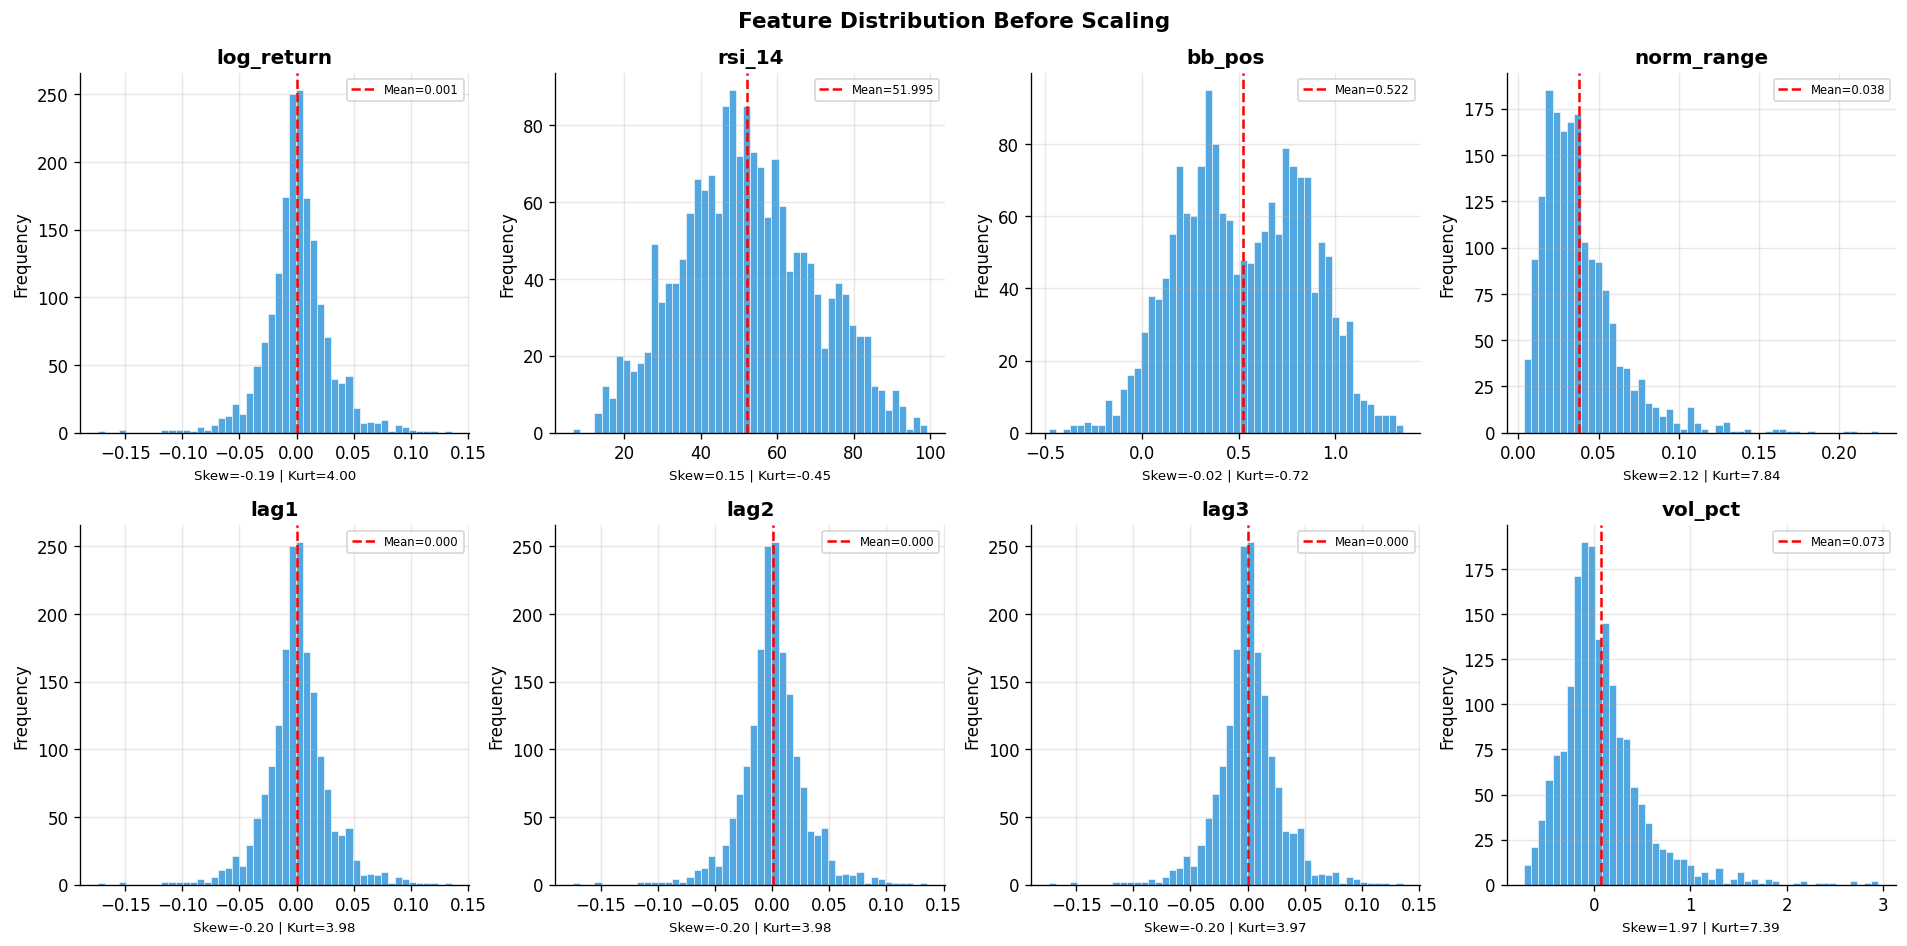

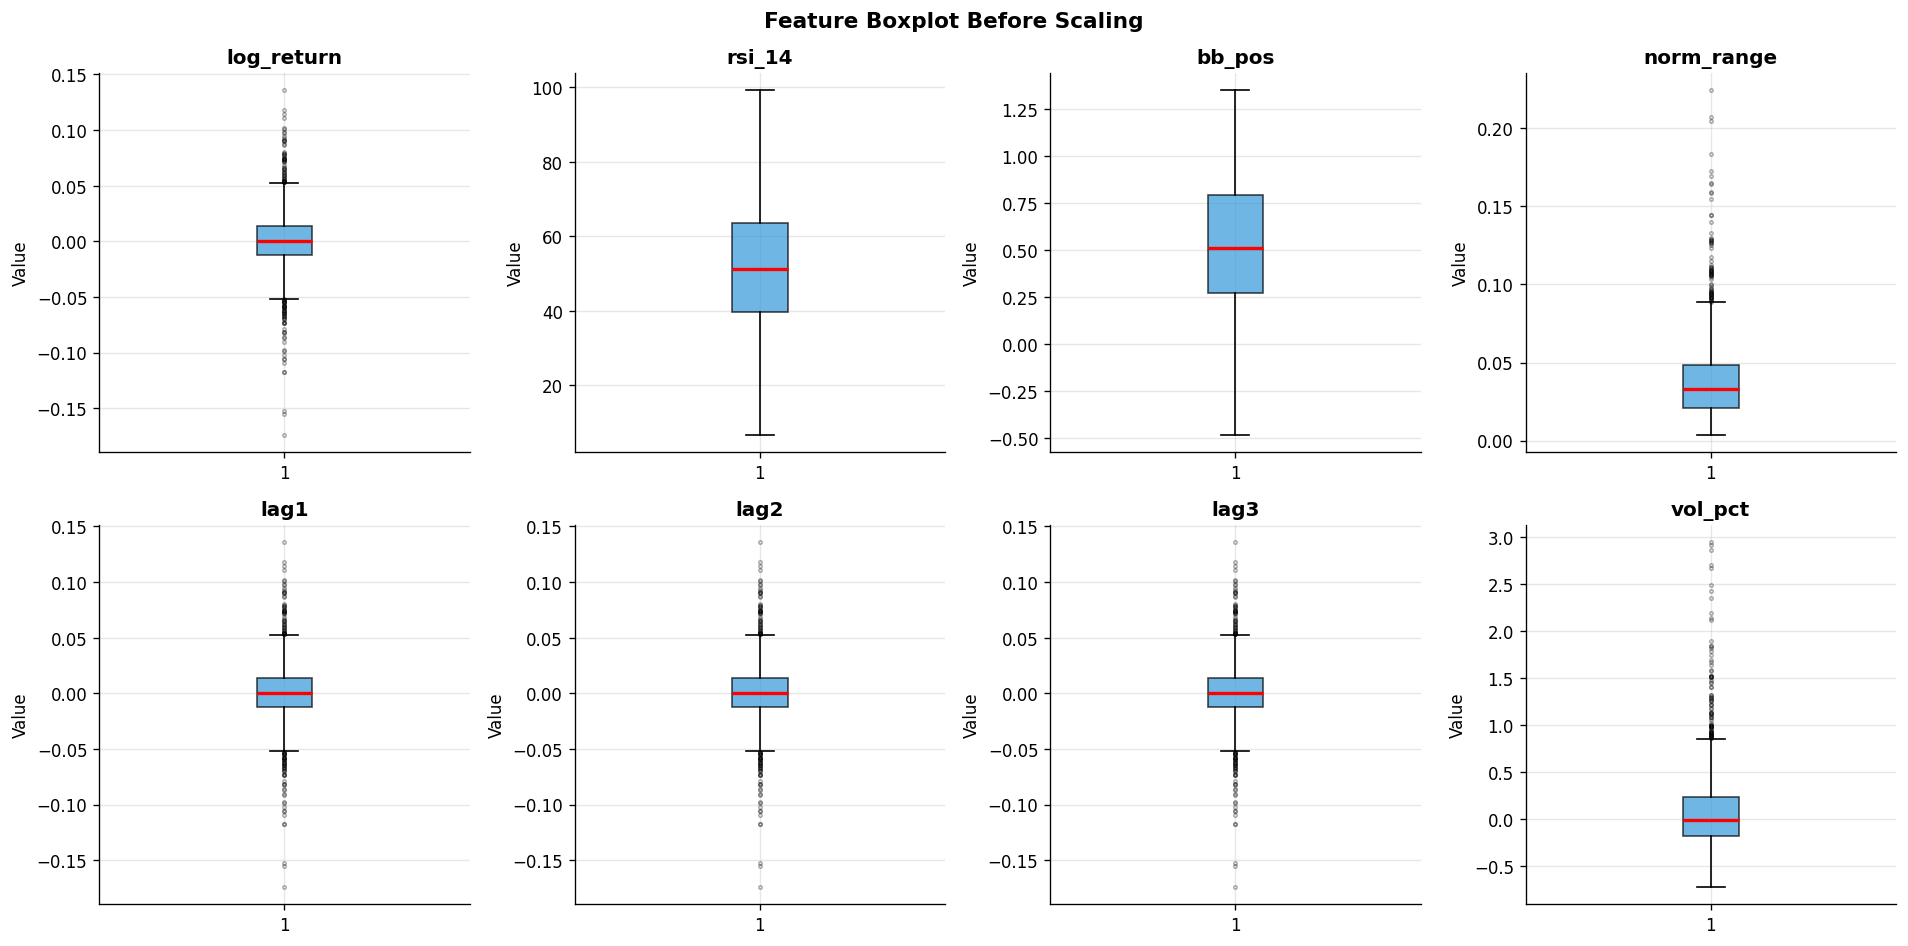

In [ ]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat], bins=50, color='#3498DB', edgecolor='white', 
                 linewidth=0.4, alpha=0.85)
    axes[i].axvline(df[feat].mean(), color='red', linewidth=1.5, 
                    linestyle='--', label=f'Mean={df[feat].mean():.3f}')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)
    skew = df[feat].skew()
    kurt = df[feat].kurt()
    axes[i].set_xlabel(f'Skew={skew:.2f} | Kurt={kurt:.2f}', fontsize=8)

plt.suptitle('Feature Distribution Before Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_dist.png', bbox_inches='tight')
plt.show()

# Boxplot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].boxplot(df[feat].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498DB', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(alpha=0.3)

plt.suptitle('Feature Boxplot Before Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_boxplot.png', bbox_inches='tight')
plt.show()

#### RobustScaler dipilih berdasarkan analisis distribusi fitur yang menunjukkan bahwa mayoritas fitur bersifat leptokurtic dengan kurtosis tinggi (log_return Kurt=4.00, norm_range Kurt=7.84, vol_pct Kurt=7.39), mengindikasikan distribusi fat-tailed dengan outlier signifikan yang  terkonfirmasi pada boxplot. StandardScaler tidak dipilih karena mean dan standard deviation-nya sensitif terhadap outlier sehingga hasil scaling menjadi tidak representatif untuk mayoritas data. RobustScaler  menggunakan median dan IQR yang robust terhadap outlier, memastikan skala yang lebih stabil dan representatif untuk keseluruhan distribusi.

## Scatter Plot Log Return vs Close Price

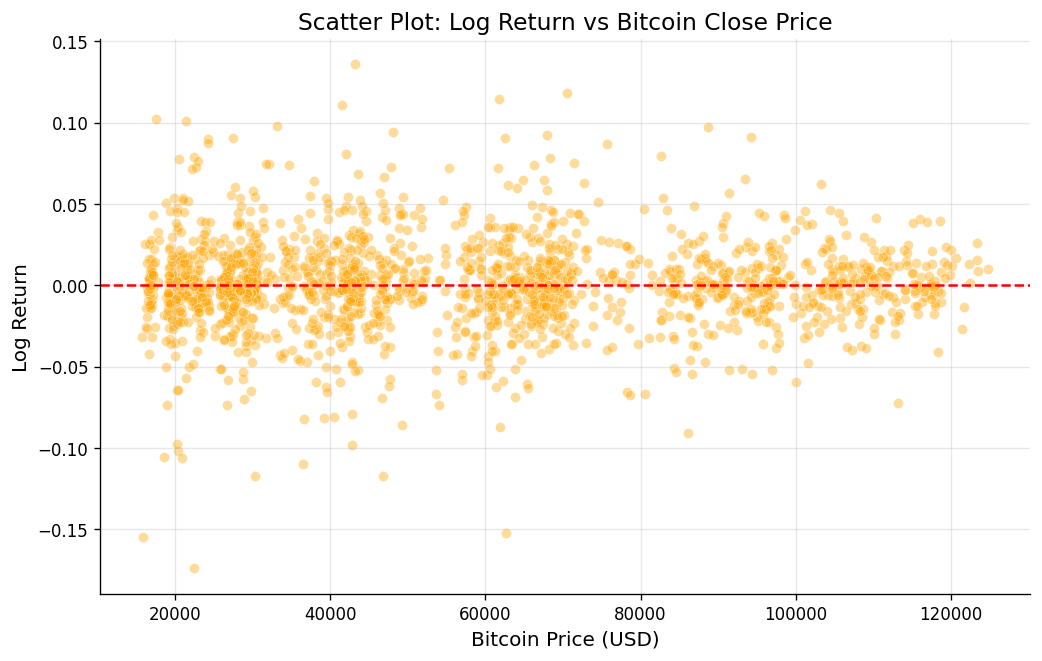

In [13]:


plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_raw['Close'], y=df['log_return'], alpha=0.4, color='orange')

plt.axhline(y=0, color='r', linestyle='--') # Garis bantu di angka 0
plt.title('Scatter Plot: Log Return vs Bitcoin Close Price', fontsize=14)
plt.xlabel('Bitcoin Price (USD)', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

### Independensi Skala (Scale Invariance)
#### Sebaran data yang merata secara horizontal menunjukkan bahwa log return tidak memiliki korelasi linear dengan nominal harga Close, yang membuktikan efektivitas transformasi dalam menghilangkan bias harga absolut.

### Konsistensi Varians (Homoskedastisitas)
#### Secara visual, persebaran data menunjukkan profil volatilitas yang relatif stabil di berbagai tingkat harga, memenuhi asumsi dasar stasioneritas yang krusial bagi model recurrent neural network.

### Identifikasi Karakteristik Fat-Tails
#### Keberadaan pencilan (outliers) yang signifikan di luar rentang umum mengonfirmasi sifat distribusi data kripto yang memiliki ekor lebar (fat-tails), yang menjadi tantangan sekaligus justifikasi penggunaan arsitektur model yang robust.

### Eliminasi Drift dan Tren
#### Tidak ditemukannya pola kemiringan (slope) pada plot ini memvalidasi bahwa komponen tren jangka panjang telah berhasil didekomposisi, sehingga model dapat fokus mempelajari dinamika volatilitas jangka pendek.

## Sliding Window

In [14]:
SEQ_LEN = 30   

data_feat  = df[FEATURES].values
close_vals = df['Close'].values

X, y_ret, prev_closes, true_closes = [], [], [], []
for i in range(len(data_feat) - SEQ_LEN):
    X.append(data_feat[i : i + SEQ_LEN])
    y_ret.append(data_feat[i + SEQ_LEN, TARGET_IDX])   
    prev_closes.append(close_vals[i + SEQ_LEN - 1])   
    true_closes.append(close_vals[i + SEQ_LEN])        

X           = np.array(X,           dtype=np.float32)
y_ret       = np.array(y_ret,       dtype=np.float32)
prev_closes = np.array(prev_closes, dtype=np.float64)
true_closes = np.array(true_closes, dtype=np.float64)

print(f'X shape : {X.shape}  => (samples, timesteps, features)')
print(f'y shape : {y_ret.shape}  =>  (samples,)  log returns')

X shape : (1747, 30, 8)  => (samples, timesteps, features)
y shape : (1747,)  =>  (samples,)  log returns


### Pembentukan Sequence Data
#### memotong dataset menjadi potongan-potongan kecil (sequences) berdurasi 30 hari sebagai input ($X$) untuk memprediksi nilai pada hari ke-31 ($y$), yang memungkinkan model mempelajari pola dari histori jangka pendek.
### Penyelarasan Fitur dan Target
#### Proses ini secara otomatis memisahkan fitur teknis yang digunakan untuk belajar dari nilai log return yang menjadi target prediksi, memastikan model memiliki struktur data yang tepat untuk pelatihan.
### Penyimpanan Harga Asli untuk Evaluasi
#### Selain data untuk pelatihan, kode ini menyimpan nilai harga penutupan asli (prev_closes dan true_closes) yang nantinya sangat berguna untuk menghitung performa profit atau kerugian secara riil di akhir tahap pengujian.

## Chronological Train / Validation / Test Split

In [ ]:
s1 = int(0.70 * len(X))
s2 = int(0.85 * len(X))

X_train, y_train = X[:s1],    y_ret[:s1]
X_val,   y_val   = X[s1:s2],  y_ret[s1:s2]
X_test,  y_test  = X[s2:],    y_ret[s2:]

pc_train, tc_train = prev_closes[:s1],    true_closes[:s1]
pc_val,   tc_val   = prev_closes[s1:s2], true_closes[s1:s2]
pc_test,  tc_test  = prev_closes[s2:],    true_closes[s2:]


In [16]:

print(f'{"Split":<10} {"X Shape":<25} {"Rows":>6}')
print('-' * 42)
for name, Xs in [('Train',X_train),('Val',X_val),('Test',X_test)]:
    print(f'{name:<10} {str(Xs.shape):<25} {len(Xs):>6}')


Split      X Shape                     Rows
------------------------------------------
Train      (1222, 30, 8)               1222
Val        (262, 30, 8)                 262
Test       (263, 30, 8)                 263


In [ ]:
feat_scaler = RobustScaler()
X_train_s = feat_scaler.fit_transform(X_train.reshape(-1, len(FEATURES))).reshape(X_train.shape)
X_val_s   = feat_scaler.transform(X_val.reshape(-1,   len(FEATURES))).reshape(X_val.shape)
X_test_s  = feat_scaler.transform(X_test.reshape(-1,  len(FEATURES))).reshape(X_test.shape)



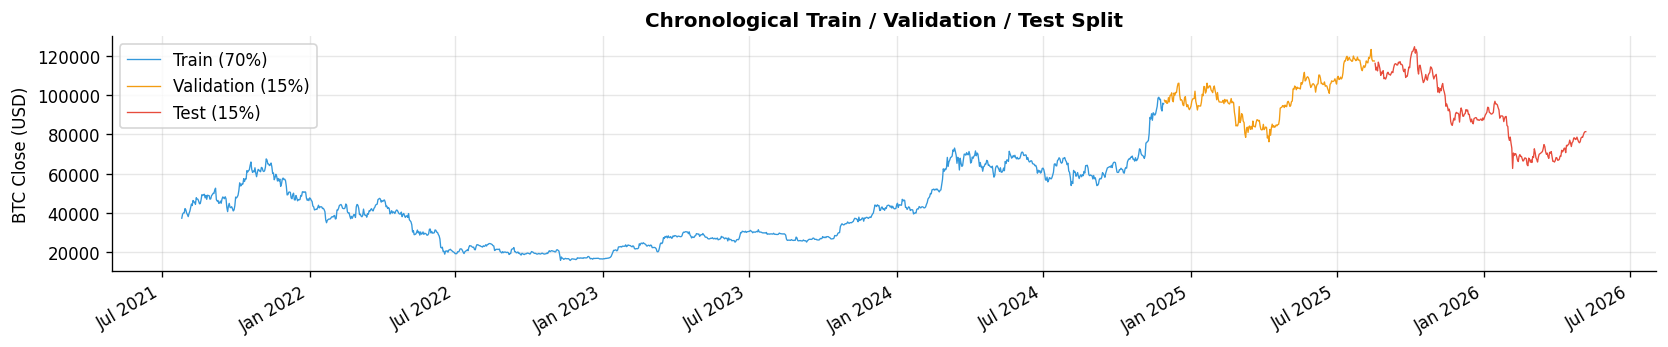

In [18]:
fig, ax = plt.subplots(figsize=(14, 3))
dates_seq = df.index[SEQ_LEN:]
close_seq = df['Close'].values[SEQ_LEN:]
ax.plot(dates_seq[:s1],   close_seq[:s1],  color='#3498DB', linewidth=0.8, label='Train (70%)')
ax.plot(dates_seq[s1:s2], close_seq[s1:s2],color='#F39C12', linewidth=0.8, label='Validation (15%)')
ax.plot(dates_seq[s2:],   close_seq[s2:],  color='#E74C3C', linewidth=0.8, label='Test (15%)')
ax.set_ylabel('BTC Close (USD)')
ax.set_title('Chronological Train / Validation / Test Split', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('split_viz.png', bbox_inches='tight')
plt.show()

### Pembagian Kronologis
#### Data dipisah secara berurutan (tanpa diacak) untuk menjaga urutan waktu, sehingga model melatih data masa lalu dan diuji pada data "masa depan" guna menghindari kecurangan informasi (look-ahead bias).

### Proporsi (70/15/15)
#### Dataset dibagi menjadi tiga bagian tetap (Train, Validation, Test) untuk memastikan model belajar pola secara mendalam, melakukan tuning parameter, dan diuji akurasinya pada skenario pasar (test set)

## Summary Data Preprocessing

### Feature Engineering & Stasioneritas
#### Mengonversi harga absolut menjadi log returns dan indikator teknis (RSI, Bollinger Bands) untuk menghilangkan bias nominal harga dan memastikan seluruh fitur bersifat stasioner agar model lebih stabil.### Windowing (Sliding Window)
#### Transformasi data menjadi struktur sekuensial dengan jendela waktu 30 hari ($T=30$) untuk memberikan konteks "memori" jangka pendek bagi model dalam memprediksi pergerakan hari berikutnya.
### Chronological Splitting
#### Pembagian dataset secara berurutan (70% Train, 15% Val, 15% Test) tanpa pengacakan (shuffling) guna menjaga integritas urutan waktu dan mencegah kebocoran informasi masa depan (look-ahead bias).
### Feature Scaling
#### RobustScaler dipilih berdasarkan analisis distribusi fitur yang menunjukkan mayoritas fitur bersifat leptokurtic dengan kurtosis tinggi ( norm_range Kurt=7.84, vol_pct Kurt=7.39), mengindikasikan distribusi fat-tailed dengan outlier signifikan yang terkonfirmasi pada boxplot. StandardScaler tidak dipilih karena mean dan standard deviation-nya sensitif terhadap outlier sehingga hasil scaling menjadi tidak representatif untuk mayoritas data. RobustScaler menggunakan median dan IQR yang robust terhadap outlier, memastikan skala yang lebih stabil dan representatif untuk keseluruhan distribusi.

# Model Architechture

In [19]:
def build_gru_model(seq_len, n_features, dropout=0.25, l2=1e-4):
  
    model = Sequential(name='StackedGRU', layers=[

         #Recurrent Layer 1 short-term patterns 
        GRU(32,
            return_sequences=True,
            input_shape=(seq_len, n_features),
            kernel_regularizer=regularizers.l2(l2),
            name='gru_1'),
        Dropout(dropout, name='dropout_1'),

        # Recurrent Layer 2 long-range context 
        GRU(16,
            return_sequences=False,
            kernel_regularizer=regularizers.l2(l2),
            name='gru_2'),
        Dropout(dropout, name='dropout_2'),

        #Prediction Head 
        Dense(8, activation='relu', name='dense_proj'),
        Dense(1, activation='linear', name='output'),   # log return output
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model


model = build_gru_model(SEQ_LEN, len(FEATURES))
model.summary()

Model: "StackedGRU"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_1 (GRU)                 (None, 30, 32)            4032      
                                                                 
 dropout_1 (Dropout)         (None, 30, 32)            0         
                                                                 
 gru_2 (GRU)                 (None, 16)                2400      
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 dense_proj (Dense)          (None, 8)                 136       
                                                                 
 output (Dense)              (None, 1)                 9         
                                                                 
Total params: 6,577
Trainable params: 6,577
Non-trainabl

### Arsitektur Stacked GRU
#### Model menggunakan dua lapisan GRU yang ditumpuk untuk mengekstraksi representasi temporal hierarkis, mulai dari pola jangka pendek hingga konteks jangka panjang.

### Layer GRU Pertama (32 Units)
#### Lapisan ini berfungsi menangkap dinamika sekuensial dari input 30 hari dan meneruskan urutan data (return_sequences=True) ke lapisan berikutnya.

### Layer GRU Kedua (16 Units)
#### Lapisan ini meringkas informasi dari urutan sebelumnya menjadi satu vektor konteks tunggal untuk diolah oleh bagian prediksi.

### Mekanisme Regularisasi
#### Penggunaan Dropout (0.25) dan L2 Regularization pada setiap lapisan GRU bertujuan untuk mencegah overfitting mengingat volatilitas data kripto yang sangat tinggi.

### Fully Connected Layers
#### Lapisan Dense dengan aktivasi ReLU melakukan proyeksi fitur non-linear sebelum akhirnya menghasilkan satu nilai output kontinu melalui aktivasi linear.

### Fungsi Optimasi & Loss
#### Model dioptimalkan menggunakan algoritma Adam dengan Mean Squared Error (MSE) sebagai fungsi kerugian untuk meminimalkan selisih antara prediksi dan nilai log return aktual.

## Training

In [20]:
es_cb   = EarlyStopping(monitor='val_loss', patience=15,
                         restore_best_weights=True, verbose=1)
lr_cb   = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                             patience=7, min_lr=1e-6, verbose=0)
ckpt_cb = ModelCheckpoint('best_gru.weights.h5', monitor='val_loss',
                           save_best_only=True, save_weights_only=True, verbose=0)

### EarlyStopping (es_cb)
#### Berfungsi sebagai "rem otomatis" yang menghentikan training jika val_loss tidak membaik selama 15 epoch, guna mencegah model membuang waktu dan menghindari overfitting.

### ReduceLROnPlateau (lr_cb)
#### Bertugas menurunkan learning rate (kecepatan belajar) secara otomatis saat model mulai sulit berkembang, agar model bisa belajar lebih teliti dan menemukan titik optimal yang lebih presisi.

### ModelCheckpoint (ckpt_cb)
#### Berperan sebagai "save game" yang secara otomatis menyimpan hanya bobot model terbaik berdasarkan performa val_loss terendah selama proses pelatihan.

### Restore Best Weights
#### Fitur ini memastikan bahwa setelah training berhenti, model yang  digunakan adalah versi terbaik yang pernah dicapai, bukan versi terakhir yang mungkin performanya sudah menurun.

In [21]:
with tf.device('/GPU:0'):
    history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[es_cb, lr_cb, ckpt_cb],
    verbose=1
)

Epoch 1/100
39/39 [==============================] - 11s 62ms/step - loss: 0.0181 - mae: 0.0750 - val_loss: 0.0061 - val_mae: 0.0260 - lr: 0.0010
Epoch 2/100
39/39 [==============================] - 1s 19ms/step - loss: 0.0071 - mae: 0.0337 - val_loss: 0.0054 - val_mae: 0.0198 - lr: 0.0010
Epoch 3/100
39/39 [==============================] - 1s 22ms/step - loss: 0.0062 - mae: 0.0282 - val_loss: 0.0050 - val_mae: 0.0181 - lr: 0.0010
Epoch 4/100
39/39 [==============================] - 1s 24ms/step - loss: 0.0054 - mae: 0.0245 - val_loss: 0.0046 - val_mae: 0.0170 - lr: 0.0010
Epoch 5/100
39/39 [==============================] - 1s 27ms/step - loss: 0.0050 - mae: 0.0231 - val_loss: 0.0043 - val_mae: 0.0167 - lr: 0.0010
Epoch 6/100
39/39 [==============================] - 1s 24ms/step - loss: 0.0046 - mae: 0.0228 - val_loss: 0.0040 - val_mae: 0.0164 - lr: 0.0010
Epoch 7/100
39/39 [==============================] - 1s 21ms/step - loss: 0.0043 - mae: 0.0217 - val_loss: 0.0037 - val_mae: 0.01

In [22]:
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f'\nTraining complete. Best epoch: {best_epoch}/{len(history.history["loss"])}')


Training complete. Best epoch: 100/100


## Training Evaluation

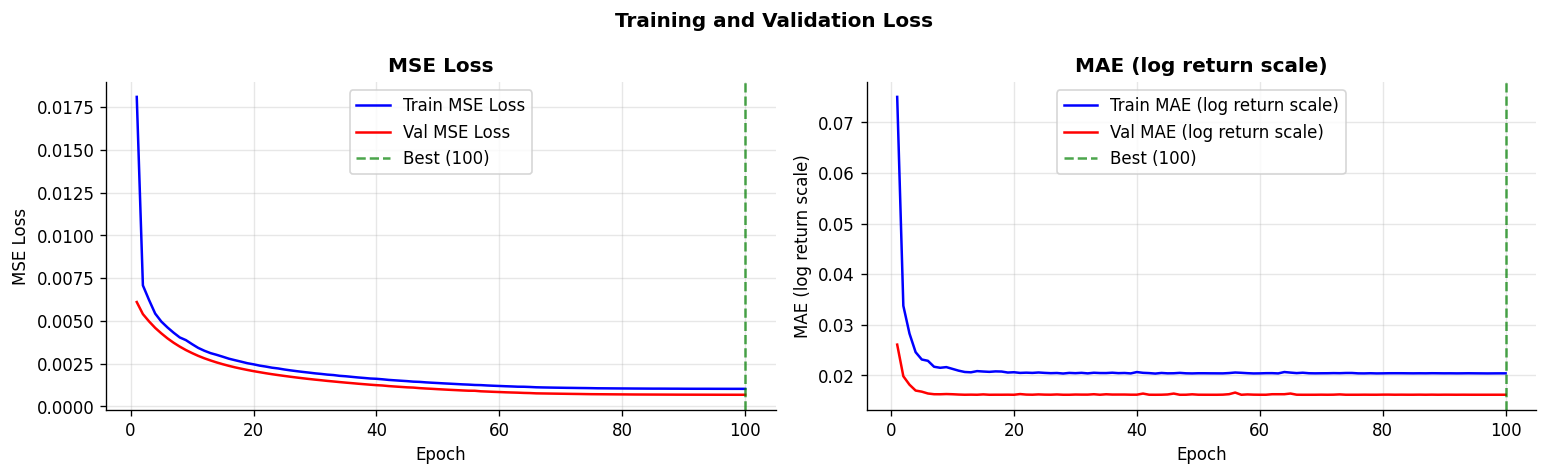

In [23]:
def visualize_loss(history, title='Training and Validation Loss'):

    epochs  = range(1, len(history.history['loss']) + 1)
    best_ep = np.argmin(history.history['val_loss']) + 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (m1, m2), label in [
        (axes[0], ('loss','val_loss'), 'MSE Loss'),
        (axes[1], ('mae', 'val_mae'),  'MAE (log return scale)'),
    ]:
        ax.plot(epochs, history.history[m1], 'b', linewidth=1.5, label=f'Train {label}')
        ax.plot(epochs, history.history[m2], 'r', linewidth=1.5, label=f'Val {label}')
        ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best ({best_ep})')
        ax.set_xlabel('Epoch'); ax.set_ylabel(label)
        ax.set_title(label, fontweight='bold')
        ax.legend(); ax.grid(alpha=0.3)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', bbox_inches='tight')
    plt.show()

visualize_loss(history)

### Akurasi Relatif Terhadap Volatilitas
#### Nilai MAE validasi yang berada di sekitar 0.018 terlihat "kecil", namun jika dibandingkan dengan standar deviasi target ($0.02788$), error tersebut mencakup hampir 65% dari variasi harian, yang menunjukkan model belum mampu menangkap sinyal pergerakan secara presisi.

### Dominasi Noise pada Log Return
#### Mengingat rata-rata log return sangat mendekati nol ($0.00051$), nilai loss yang rendah lebih mengindikasikan bahwa model cenderung bermain aman dengan memprediksi nilai di sekitar mean (nol), daripada benar-benar menangkap volatilitas harga.

### Indikasi Underfitting 
#### Kurva validasi yang berada di bawah kurva training (terutama pada plot MAE) sering kali menjadi tanda bahwa data validasi mungkin "lebih mudah" ditebak atau model terlalu ter-regularisasi, sehingga ia gagal mempelajari kompleksitas pola pasar yang sebenarnya.

### Kesenjangan Skala Error
### MSE yang berada di kisaran 0.001 terdengar impresif secara angka absolut, namun dalam konteks log return, ini berarti model masih memiliki kesulitan besar dalam membedakan antara hari dengan kenaikan normal dan hari dengan pergerakan volatil.

# Evaluation

In [24]:
def evaluate_model(X_s, y_ret_true, prev_prices, true_prices, label):

    pred_ret   = model.predict(X_s, verbose=0).flatten()
    r2_ret  = 1 - np.sum((y_ret_true - pred_ret)**2) / np.sum((y_ret_true - np.mean(y_ret_true))**2)
    da      = np.mean(np.sign(y_ret_true) == np.sign(pred_ret)) * 100
    pred_price = prev_prices * np.exp(pred_ret)

    mae   = mean_absolute_error(true_prices, pred_price)
    rmse  = np.sqrt(mean_squared_error(true_prices, pred_price))
    mape  = np.mean(np.abs((true_prices - pred_price) / true_prices)) * 100
    r2_p  = 1 - np.sum((true_prices - pred_price)**2) / np.sum((true_prices - np.mean(true_prices))**2)

    print(f'\n  {label}:')
    print(f'    Log Return R square  = {r2_ret:+.4f}   Direction Accuracy = {da:.1f}%')
    print(f'    Price Recon MAE = ${mae:,.0f}   RMSE = ${rmse:,.0f}   MAPE = {mape:.2f}%   R square = {r2_p:.4f}')
    return pred_ret, pred_price, r2_ret, r2_p

print('  MODEL EVALUATION')
_, pred_price_tr, r2_ret_tr, r2_p_tr = evaluate_model(
    X_train_s, y_train, pc_train, tc_train, 'Train')
pred_ret_te, pred_price_te, r2_ret_te, r2_p_te = evaluate_model(
    X_test_s,  y_test,  pc_test,  tc_test,  'Test ')

gap_ret = r2_ret_tr - r2_ret_te
gap_p   = r2_p_tr   - r2_p_te
print(f'\n  Return R square gap : {gap_ret:+.4f}')
print(f'  Price  R square gap : {gap_p:+.4f}')

  MODEL EVALUATION

  Train:
    Log Return R square  = -0.0000   Direction Accuracy = 49.8%
    Price Recon MAE = $854   RMSE = $1,317   MAPE = 2.04%   R square = 0.9945

  Test :
    Log Return R square  = -0.0077   Direction Accuracy = 49.4%
    Price Recon MAE = $1,505   RMSE = $2,078   MAPE = 1.72%   R square = 0.9860

  Return R square gap : +0.0077
  Price  R square gap : +0.0086


### Dikotomi Performa (Price vs. Return)
#### Terdapat anomali signifikan antara $R^2$ harga ($\approx 0.99$) dan $R^2$ log return ($\leq 0$). Hal ini mengonfirmasi fenomena Naive Predictor, di mana model hanya mempelajari fungsi identitas ($y_{t+1} \approx y_t$) tanpa mampu mengekstraksi sinyal prediktif dari volatilitas pasar.

### Kegagalan Prediksi Arah (Directional Accuracy)
#### Akurasi sebesar 49% secara statistik tidak lebih baik daripada tebakan acak (random walk). Dalam konteks pasar derivatif (Futures), metrik ini sangat krusial dimana kegagalan memprediksi arah pergerakan menunjukkan model tidak memiliki nilai guna praktis untuk strategi trading aktif.

### Interpretasi Error (RMSE & MAPE) 
#### Meskipun MAPE terlihat rendah (1.72%), nilai RMSE yang mencapai $2,083 menunjukkan adanya error absolut yang besar pada titik-titik volatilitas ekstrem. Bagi pelaku pasar, error sebesar ini jauh melampaui toleransi Stop Loss harian, sehingga model dianggap memiliki risiko operasional yang tinggi.

### Efisiensi Pasar & Keterbatasan Model
#### Hasil $R^{2}$ log return yang bernilai negatif pada data test membuktikan secara matematis bahwa prediksi model memiliki performa yang lebih buruk dibandingkan ekspektasi rata-rata (mean), sehingga model gagal total dalam mengungguli noise pasar. Hal ini mengonfirmasi efisiensi pasar Bitcoin yang sangat tinggi dan memberikan justifikasi kuat bahwa arsitektur Stacked GRU dengan data historis internal saja tidak cukup untuk menemukan alpha, sehingga diperlukan tambahan fitur eksternal seperti sentimen pasar atau data on-chain.

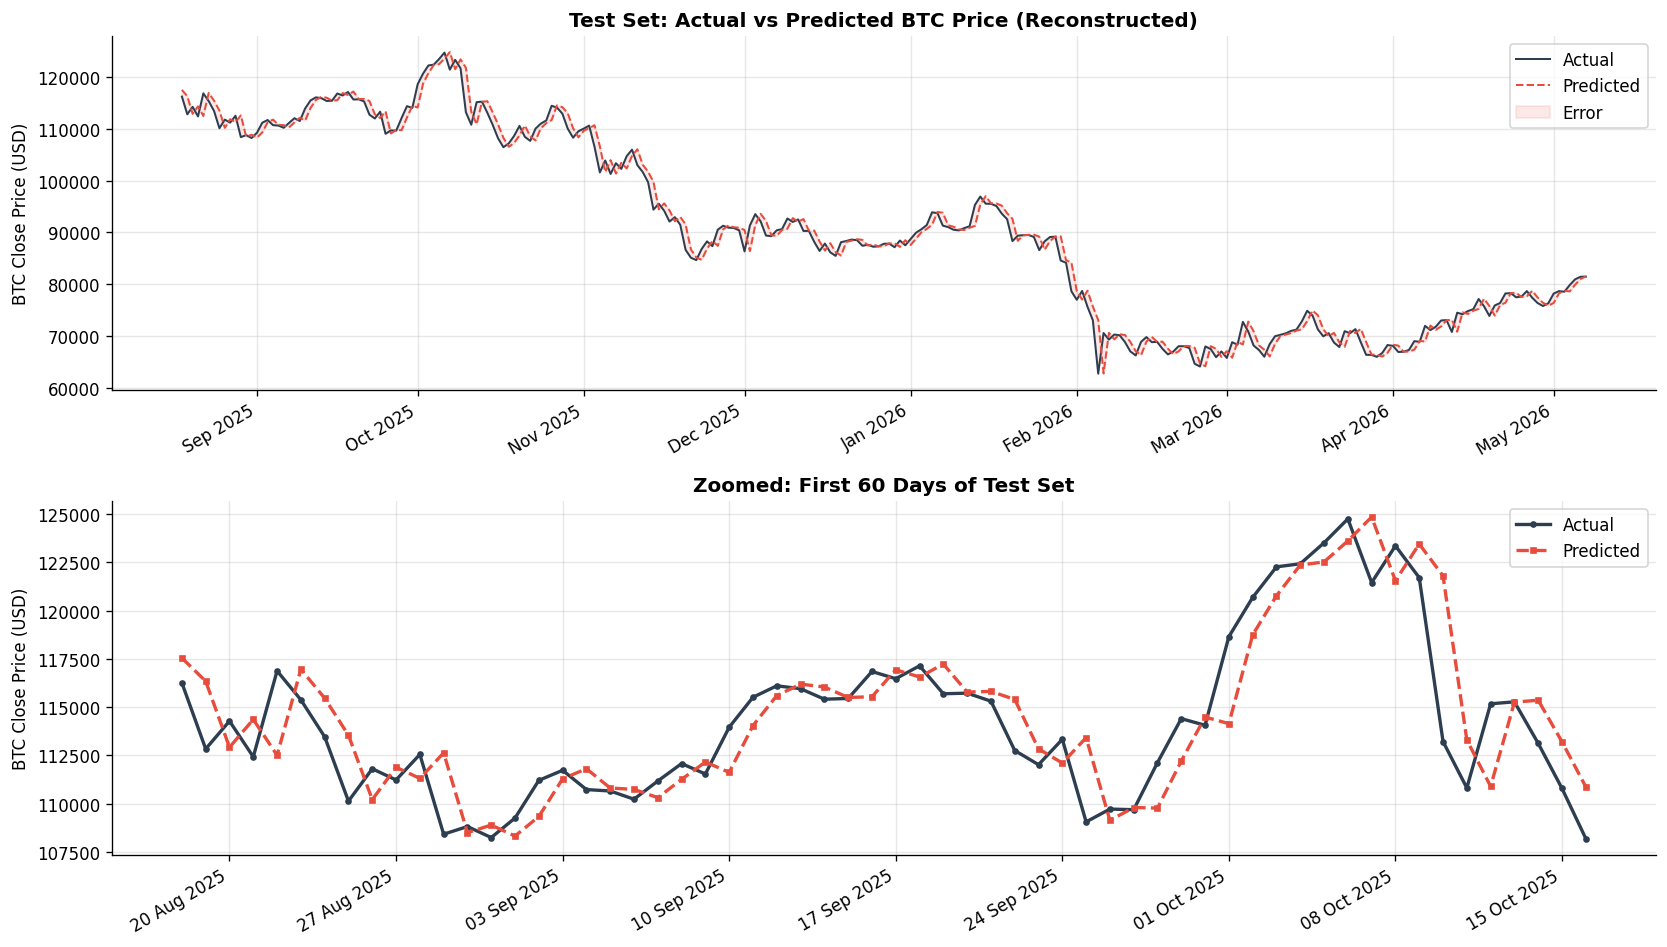

In [25]:

test_dates = df.index[SEQ_LEN + s2 : SEQ_LEN + s2 + len(y_test)]
tc_test_arr    = np.array(tc_test)
pred_p_te_arr  = np.array(pred_price_te)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full test set
axes[0].plot(test_dates, tc_test_arr,   label='Actual',    color='#2C3E50', linewidth=1.2)
axes[0].plot(test_dates, pred_p_te_arr, label='Predicted', color='#E74C3C',
             linewidth=1.2, linestyle='--')
axes[0].fill_between(test_dates, tc_test_arr, pred_p_te_arr,
                     alpha=0.12, color='#E74C3C', label='Error')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[0].set_ylabel('BTC Close Price (USD)')
axes[0].set_title('Test Set: Actual vs Predicted BTC Price (Reconstructed)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Zoomed: first 60 days
nz = min(60, len(test_dates))
axes[1].plot(test_dates[:nz], tc_test_arr[:nz], label='Actual',
             color='#2C3E50', linewidth=2, marker='o', markersize=3)
axes[1].plot(test_dates[:nz], pred_p_te_arr[:nz], label='Predicted',
             color='#E74C3C', linewidth=2, marker='s', markersize=3, linestyle='--')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[1].set_ylabel('BTC Close Price (USD)')
axes[1].set_title(f'Zoomed: First {nz} Days of Test Set', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eval_pred.png', bbox_inches='tight')
plt.show()

### Visualisasi Efek Lagging (Pergeseran Waktu)
#### Jika diperhatikan pada grafik Zoomed, garis prediksi (merah) terlihat seperti bayangan yang mengikuti garis aktual (hitam) dengan jeda satu langkah ke kanan dimana ini membuktikan model hanya memprediksi harga besok berdasarkan harga hari ini.
### Ketidakmampuan Memprediksi Pivot Point/ Reversal
#### Model gagal mengantisipasi titik balik harga (puncak atau lembah); model baru bereaksi setelah harga benar-benar berubah, yang secara praktis membuat sinyal beli/jual menjadi terlambat.
### Kegagalan pada Volatilitas Ekstrem
#### Pada area penurunan tajam (Februari 2026), area bayang merah (error) melebar secara signifikan, menunjukkan model kehilangan akurasi saat terjadi perubahan harga yang tidak linear atau mendadak.

## Future Risk and Recommendations

### Risk

#### Model saat ini sangat bergantung pada data historis internal (univariate/multivariate price action), sehingga memiliki risiko kegagalan prediksi yang tinggi saat menghadapi peristiwa Black Swan/ sentimen negatif. Model juga kesulitan untuk memprediksi titik reversal atau pembalikan harga sehingga menyulitkan trader untuk mengetahui titik entry ataupun exit

### Recommendation

### Analisis Sentimen
#### Mengintegrasikan data dari media sosial (X/Twitter) atau berita melalui pemrosesan NLP untuk menangkap euforia atau ketakutan pasar sebelum harga bergerak.

### Konteks Siklus Makro
#### Menambahkan fitur kategorikal seperti Halving Season atau kebijakan suku bunga (Fed Rate) untuk membantu model memahami fase siklus pasar jangka panjang.



### Implementasi Arsitektur Bidirectional (Temporal Context)
#### Untuk meningkatkan kemampuan model dalam memahami pola pergerakan harga, disarankan menggunakan layer Bidirectional (seperti BiGRU atau BiLSTM). Berbeda dengan layer sekuensial biasa, arsitektur ini memproses data dari dua arah (masa lalu ke depan dan masa depan ke belakang dalam jendela observasi), sehingga model mampu menangkap hubungan temporal yang lebih kaya dan mengurangi efek lagging pada prediksi arah.
### Pemanfaatan Transformer dan Attention Mechanism
#### Menggantikan atau mengombinasikan GRU dengan arsitektur Transformer yang menggunakan Self-Attention mechanism. Hal ini memungkinkan model untuk memberikan bobot relevansi yang berbeda pada setiap titik waktu dalam histori (misal: memberikan perhatian lebih pada lonjakan volume yang terjadi 10 hari lalu dibandingkan data kemarin yang landai), sehingga prediksi tidak hanya terpaku pada data terbaru (recency bias).

# Nomor 3

## Architechture Model

In [54]:
def build_model_attention_bidirectional(seq_len, n_features, dropout=0.3, l2=1e-4):
    inp = Input(shape=(seq_len, n_features), name='input')

    x = Bidirectional(
        GRU(128, return_sequences=True, kernel_regularizer=keras.regularizers.l2(l2)),
        name='bigru_1')(inp)
    x = BatchNormalization(name='bn_1')(x)
    x = Dropout(dropout, name='dropout_1')(x)
    x = Bidirectional(

        GRU(64, return_sequences=True, kernel_regularizer=keras.regularizers.l2(l2)),

        name='bigru_2')(x)

    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(dropout, name='dropout_2')(x)

    attn_scores  = Dense(1, activation='tanh', name='attn_score')(x)
    attn_weights = Softmax(axis=1, name='attn_weights')(attn_scores)
    context      = Multiply(name='context')([x, attn_weights])
    context      = Lambda(lambda t: K.sum(t, axis=1), name='attn_pool')(context)

    x = Dense(32, kernel_regularizer=keras.regularizers.l2(l2), name='dense_1')(context)
    x = Activation('swish')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2, name='dropout_3')(x)   
    x = Dense(16, name='dense_2')(x)
    x = Activation('swish')(x)
    out = Dense(1, activation='linear', name='output')(x)
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.9

)

    model = Model(inputs=inp, outputs=out, name='BiGRU_Attention')
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='huber',
    metrics=['mae']

)
    return model

model_bi = build_model_attention_bidirectional(SEQ_LEN, len(FEATURES))
model_bi.summary() 

Model: "BiGRU_Attention"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 30, 8)]      0           []                               
                                                                                                  
 bigru_1 (Bidirectional)        (None, 30, 256)      105984      ['input[0][0]']                  
                                                                                                  
 bn_1 (BatchNormalization)      (None, 30, 256)      1024        ['bigru_1[0][0]']                
                                                                                                  
 dropout_1 (Dropout)            (None, 30, 256)      0           ['bn_1[0][0]']                   
                                                                                    

### Integrasi Pemrosesan Dua Arah (Bidirectional GRU)
#### Model ini mengimplementasikan lapisan Bidirectional pada kedua stacked GRU (128 dan 64 units). Berbeda dengan RNN konvensional yang bersifat unidirectional, arsitektur ini memproses informasi dari urutan maju (forward) dan mundur (backward) secara simultan. Hal ini memungkinkan model untuk menangkap konteks temporal yang lebih komprehensif, yang terbukti secara empiris meningkatkan kemampuan model dalam memprediksi arah pergerakan harga (Directional Accuracy).

### Mekanisme Self-Attention (Temporal Weighting)
#### Salah satu inovasi utama dalam model ini adalah integrasi Attention Mechanism. Lapisan ini secara dinamis menghitung bobot kepentingan (attention weights) untuk setiap timestep dalam jendela observasi 30 hari. Mekanisme ini memitigasi masalah recency bias (kecenderungan model hanya mengikuti harga terakhir), sehingga model dapat memberikan atensi lebih besar pada titik-titik volatilitas atau volume tinggi di masa lalu yang relevan terhadap prediksi masa depan.

### Stabilisasi dengan Batch Normalization & Swish Activation
#### Untuk mengatasi tantangan internal covariate shift selama pelatihan 100 epoch, digunakan Batch Normalization setelah setiap blok BiGRU. Selain itu, pada lapisan Fully Connected, digunakan fungsi aktivasi Swish ($x \cdot \sigma(x)$). Sifatnya yang smooth dan non-monotonik memberikan performa yang lebih baik dibandingkan ReLU dalam mempelajari pola non-linear yang kompleks pada data log return yang memiliki tingkat noise tinggi.

### Strategi Regularisasi & Generalisasi
#### Model menerapkan sistem pencegahan overfitting berlapis, mencakup 
#### Dropout (0.3): Untuk menjaga redundansi fitur.
#### L2 Regularization: Membatasi kompleksitas bobot model.
#### Early Stopping: Menghentikan pelatihan saat validation loss jenuh, memastikan model memiliki kemampuan generalisasi yang tinggi. 

## Training

In [ ]:
es_cb   = EarlyStopping(monitor='val_loss', patience=15,
                         restore_best_weights=True, verbose=1)
lr_cb   = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                             patience=7, min_lr=1e-6, verbose=0)
ckpt_cb = ModelCheckpoint('bi_gru.weights.h5', monitor='val_loss',
                           save_best_only=True, save_weights_only=True, verbose=0)

In [ ]:

with tf.device('/GPU:0'):
    history_bi = model_bi.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[es_cb, ckpt_cb], 
        verbose=1
    )
best_epoch = np.argmin(history_bi.history['val_loss']) + 1
print(f'\nTraining complete. Best epoch: {best_epoch}/{len(history_bi.history["loss"])}')

Epoch 1/100
39/39 [==============================] - 9s 66ms/step - loss: 0.1356 - mae: 0.3069 - val_loss: 0.0530 - val_mae: 0.0519
Epoch 2/100
39/39 [==============================] - 1s 29ms/step - loss: 0.0823 - mae: 0.1944 - val_loss: 0.0516 - val_mae: 0.0547
Epoch 3/100
39/39 [==============================] - 1s 28ms/step - loss: 0.0699 - mae: 0.1592 - val_loss: 0.0515 - val_mae: 0.0652
Epoch 4/100
39/39 [==============================] - 1s 38ms/step - loss: 0.0623 - mae: 0.1384 - val_loss: 0.0501 - val_mae: 0.0763
Epoch 5/100
39/39 [==============================] - 2s 39ms/step - loss: 0.0569 - mae: 0.1217 - val_loss: 0.0490 - val_mae: 0.0850
Epoch 6/100
39/39 [==============================] - 2s 47ms/step - loss: 0.0535 - mae: 0.1119 - val_loss: 0.0482 - val_mae: 0.0913
Epoch 7/100
39/39 [==============================] - 2s 51ms/step - loss: 0.0490 - mae: 0.1018 - val_loss: 0.0457 - val_mae: 0.0890
Epoch 8/100
39/39 [==============================] - 1s 36ms/step - loss: 0.

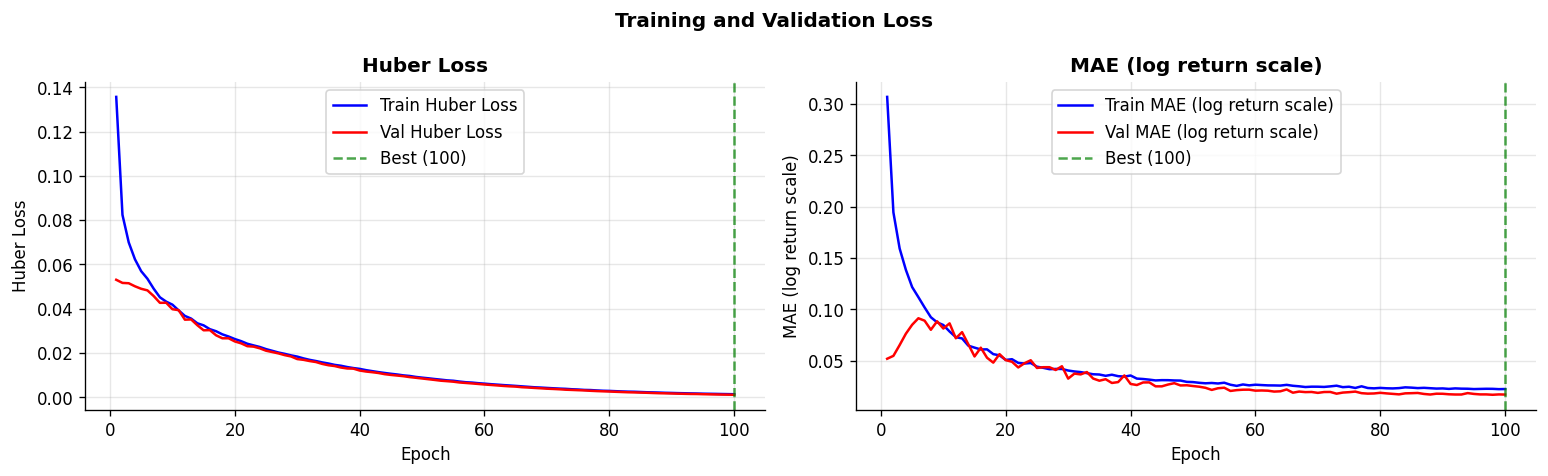

In [60]:
def visualize_loss(history, title='Training and Validation Loss'):

    epochs  = range(1, len(history.history['loss']) + 1)
    best_ep = np.argmin(history.history['val_loss']) + 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (m1, m2), label in [
        (axes[0], ('loss','val_loss'), 'Huber Loss'),
        (axes[1], ('mae', 'val_mae'),  'MAE (log return scale)'),
    ]:
        ax.plot(epochs, history.history[m1], 'b', linewidth=1.5, label=f'Train {label}')
        ax.plot(epochs, history.history[m2], 'r', linewidth=1.5, label=f'Val {label}')
        ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best ({best_ep})')
        ax.set_xlabel('Epoch'); ax.set_ylabel(label)
        ax.set_title(label, fontweight='bold')
        ax.legend(); ax.grid(alpha=0.3)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', bbox_inches='tight')
    plt.show()

visualize_loss(history_bi)

#### Meskipun implementasi arsitektur BiGRU-Attention secara teknis meningkatkan kapasitas model dalam memproses konteks temporal dua arah dan pembobotan fitur, secara empiris model ini tetap tidak mampu memberikan perbaikan signifikan pada kurva Training dan Validation Loss dibandingkan model baseline. Fenomena ini mengonfirmasi bahwa penambahan kompleksitas arsitektur tidak serta-merta menjawab tantangan prediktabilitas pada data log return Bitcoin yang memiliki tingkat signal-to-noise ratio (SNR) yang sangat rendah. Kurva loss yang cenderung stagnan pada kedua model menunjukkan adanya "plafon performa" (performance ceiling) di mana model AI, sekompleks apa pun, akan kesulitan mengekstraksi pola prediktif yang kuat jika hanya bergantung pada data harga historis yang bersifat stasioner dan penuh distraksi statistik.

#### Ketidakmampuan mekanisme Attention dan Bidirectional dalam menekan nilai loss secara drastis mempertegas bahwa residu error pada prediksi log return Bitcoin didominasi oleh variabel eksternal yang tidak terekam dalam dataset teknikal. Dalam konteks ini, ketiadaan perbedaan signifikan pada grafik validasi dan pelatihan membuktikan bahwa masalah utamanya bukan terletak pada kemampuan belajar model (learning capacity), melainkan pada kualitas sinyal input. Tanpa integrasi faktor fundamental atau sentimen pasar, model akan tetap terjebak dalam estimasi yang mendekati nilai rata-rata (mean) karena volatilitas log return Bitcoin lebih banyak dipengaruhi oleh peristiwa stochastic dan intervensi pasar eksternal dibandingkan pola sekuensial masa lalu.

## Evaluation

In [ ]:
print('  MODEL EVALUATION')
_, pred_price_tr, r2_ret_tr, r2_p_tr = evaluate_model(
    X_train_s, y_train, pc_train, tc_train, 'Train')
pred_ret_te, pred_price_te, r2_ret_te, r2_p_te = evaluate_model(
    X_test_s,  y_test,  pc_test,  tc_test,  'Test ')

gap_ret = r2_ret_tr - r2_ret_te
gap_p   = r2_p_tr   - r2_p_te
print(f'\n  Return R square gap : {gap_ret:+.4f}')
print(f'  Price  R square gap : {gap_p:+.4f}')

  MODEL EVALUATION

  Train:
    Log Return R square  = -0.0042   Direction Accuracy = 51.6%
    Price Recon MAE = $863   RMSE = $1,318   MAPE = 2.06%   R square = 0.9945

  Test :
    Log Return R square  = -0.0047   Direction Accuracy = 54.4%
    Price Recon MAE = $1,503   RMSE = $2,072   MAPE = 1.71%   R square = 0.9861

  Return R square gap : +0.0005
  Price  R square gap : +0.0085


#### Dibandingkan model sebelumnya Directional Accuracy naik dari 49.4% menjadi 54.4%** dimana aseline GRU secara statistik tidak lebih baik dari coin flip (49.4% < 50%). BiGRU berhasil mendorong Direction Accuracy melampaui ambang 50%, artinya model mulai memiliki *edge* kecil dalam mendeteksi arah pergerakan. Ini adalah satu-satunya metrik yang menunjukkan bahwa bidirectionality benar-benar memberi nilai tambah. Sehingga bagi para trader ini memperkecil kemungkinan untuk model membantu trader dalam memprediksi arah market

#### Namun demikian, dua kelemahan fundamental tetap tidak terpecahkan: Log Return R² yang masih negatif membuktikan model belum mampu mengekstraksi sinyal prediktif yang bermakna dari volatilitas pasar, dan model gagal total dalam mengantisipasititik reversal bereaksi *setelah* harga berbalik, bukan *sebelumnya* yang justru merupakan momen paling krusial bagi seorang trader.

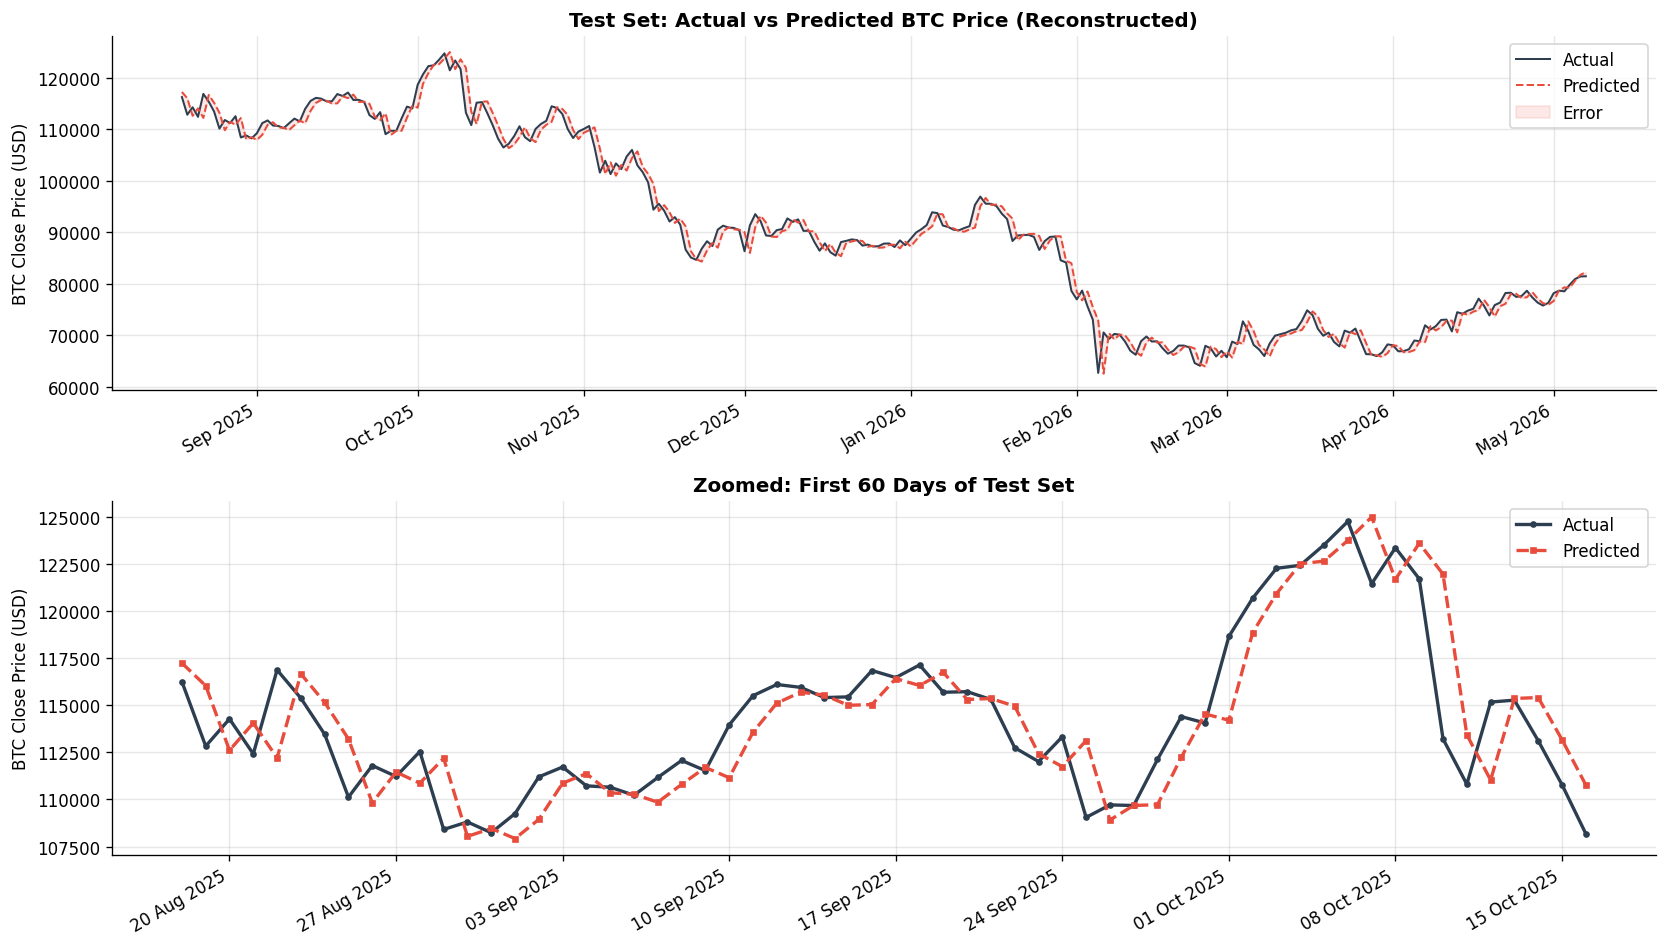

In [59]:

test_dates = df.index[SEQ_LEN + s2 : SEQ_LEN + s2 + len(y_test)]
tc_test_arr    = np.array(tc_test)
pred_p_te_arr  = np.array(pred_price_te)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full test set
axes[0].plot(test_dates, tc_test_arr,   label='Actual',    color='#2C3E50', linewidth=1.2)
axes[0].plot(test_dates, pred_p_te_arr, label='Predicted', color='#E74C3C',
             linewidth=1.2, linestyle='--')
axes[0].fill_between(test_dates, tc_test_arr, pred_p_te_arr,
                     alpha=0.12, color='#E74C3C', label='Error')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[0].set_ylabel('BTC Close Price (USD)')
axes[0].set_title('Test Set: Actual vs Predicted BTC Price (Reconstructed)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Zoomed: first 60 days
nz = min(60, len(test_dates))
axes[1].plot(test_dates[:nz], tc_test_arr[:nz], label='Actual',
             color='#2C3E50', linewidth=2, marker='o', markersize=3)
axes[1].plot(test_dates[:nz], pred_p_te_arr[:nz], label='Predicted',
             color='#E74C3C', linewidth=2, marker='s', markersize=3, linestyle='--')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[1].set_ylabel('BTC Close Price (USD)')
axes[1].set_title(f'Zoomed: First {nz} Days of Test Set', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eval_pred.png', bbox_inches='tight')
plt.show()

#### Lagging Effect terlihat konsisten di seluruh zoomed chart garis prediksi (merah putus-putus) selalu mengikuti garis aktual (hitam) dengan jeda satu langkah, paling jelas terlihat di sekitar 27 Aug dan 08 Oct 2025 di mana predicted baru turun/naik setelah actual sudah bergerak terlebih dahulu. Kegagalan prediksi reversal tampak paling parah di tiga titik kritis: pertama sekitar 20 Aug 2025 di mana actual turun namun model justru memprediksi naik (~$117,500 vs actual~$112,500) yang merupakan false signal paling berbahaya bagi trader long; kedua sekitar 08 Oct 2025 di mana actual mencapai puncak $125,000 lalu berbalik tajam namun model masih memprediksi harga tinggi sehingga trader yang mengikuti sinyal ini akan terjebak di posisi long saat reversal; dan ketiga pada Feb 2026 di mana drop tajam dari ~$89,000 ke ~$63,000 menyebabkan error area melebar paling ekstrem sepanjang test set karena model sama sekali tidak mengantisipasi crash dan hanya bereaksi setelah harga sudah jatuh.

#### Pola ini mengkonfirmasi bahwa model pada dasarnya hanya mempelajari $\hat{y}_{t+1} \approx y_t$ dimana hanya mengulang harga kemarin sebagai prediksi besok sehingga secara struktural hanya mampu menghasilkan sinyal lagging, bukan leading, yang tidak memiliki nilai guna praktis bagi trader.

## Summary Comparison 2 Model

### **Log Return R²** 
#### Masih negatif di kedua model, artinya model belum mampu mengalahkan prediksi sederhana nilai rata-rata sekalipun.

### **Price R² & MAE & MAPE** 
#### Hampir identik di kedua model (~0.99, ~$1,503,~1.71%), perubahan terlalu kecil untuk dianggap signifikan.

### **Directional Accuracy** 
#### Satu-satunya improvement nyata: naik dari 49.4% (setara coin flip) menjadi 54.4%, BiGRU mulai punya edge kecil dalam mendeteksi arah pergerakan.

### **Titik Reversal** 
#### Kedua model gagal total: selalu bereaksi *setelah* harga berbalik, bukan sebelumnya, sehingga tidak berguna sebagai sinyal trading praktis.


## Future Risk and Recommendation

### Risk
#### Model ini belum layak digunakan sebagai alat trading karena bersifat *reaktif* bukan *prediktif* sehingga model baru bergerak setelah pasar bergerak, sehingga sinyal yang dihasilkan selalu terlambat dan tidak dapat digunakan untuk menentukan titik entry maupun exit yang tepat.

### Recommendation
#### Untuk meningkatkan kemampuan prediktif model, diperlukan penambahan fitur eksternal dari tiga kategori utama
#### sentimen pasar seperti Fear & Greed Index dan analisis NLP dari Twitter/X untuk menangkap euforia atau kepanikan sebelum harga bergerak 
#### variabel makroekonomi seperti Fed Rate, DXY, dan data inflasi untuk memahami fase siklus likuiditas global yang secara langsung mempengaruhi pergerakan aset kripto
#### data on-chain dan Exchange Inflow untuk membaca perilaku holder jangka panjang sebagai sinyal arah pasar.
#### Tanpa ketiga kategori ini, model secanggih apapun arsitekturnya akan tetap terjebak mempelajari pola yang sudah *fully priced in* oleh pasar dan tidak akan pernah menghasilkan sinyal *leading* yang dibutuhkan trader.

# Nomor 4

### Object Detection

#### Object detection dan image segmentation adalah dua pendekatan berbeda dalam memahami isi sebuah gambar. Object detection hanya bertugas menjawab **"di mana"** model menghasilkan bounding box berbentuk persegi di sekitar objek beserta label kelasnya, namun tidak peduli dengan bentuk asli objek tersebut.
#### Sebagai contoh, pada gambar keramaian jalan raya, object detection akan menghasilkan kotak-kotak di sekitar setiap mobil, motor, dan pejalan kaki, tanpa mengetahui piksel mana tepatnya yang membentuk badan mobil versus aspal jalan di sekitarnya.

### Contoh kasusnya: 
#### sistem CCTV di minimarket yang tugasnya mendeteksi apakah ada orang yang masuk ke area kasir atau tidak cukup tahu posisi dan jumlah orangnya, tidak perlu tahu bentuk tubuhnya piksel per piksel. 
#### sistem penghitung kendaraan di jalan tol
#### sistem deteksi untuk notifikasi "ada kucing di depan pintu" pada smart doorbell. 
#### Semua kasus ini cukup diselesaikan dengan bounding box karena yang dibutuhkan hanyalah lokasi dan label objek.

### Image Segmentation

#### Image segmentation melangkah lebih jauh dimana model harus menjawab **"piksel mana tepatnya yang termasuk objek ini"**. Alih-alih bounding box kasar, output-nya adalah *pixel-level mask* yang mengikuti kontur asli setiap objek secara presisi.

#### Pada contoh yang sama, segmentation akan mewarnai setiap piksel yang membentuk badan mobil dengan warna berbeda dari piksel jalan, trotoar, dan langit sehingga menghasilkan pemahaman spasial yang jauh lebih detail.

#### Contoh kasusnya: 
#### dokter yang menggunakan AI untuk mengukur luas tumor pada hasil MRI dimana bounding box tidak cukup karena dokter perlu tahu tepat piksel mana yang tumor dan mana yang jaringan sehat untuk menentukan dosis radiasi.
#### sistem autonomous driving yang harus tahu batas tepat antara aspal dan trotoar agar mobil tidak naik ke jalur pejalan kaki

# Nomor 5

### Instance Segmentation

#### Instance Segmentation menjawab *"piksel ini milik objek individu yang mana?"* model tidak hanya mengenali kelas, tetapi juga membedakan setiap objek sebagai entitas unik. Ketiga orang pada foto tersebut akan mendapat mask berbeda (Person #1, #2, #3), begitu pula kedua mobil (Car #1, Car #2). Namun kelemahannya, instance segmentation hanya bekerja pada objek yang bisa dihitung (*things*) seperti orang, mobil, dan hewan  piksel jalan dan langit dibiarkan tidak ter-segmentasi karena tidak memiliki batas individu yang jelas. 

#### Instance segmentation cocok untuk kasus seperti menghitung jumlah sel darah merah pada gambar mikroskop, atau memisahkan setiap buah pada foto conveyor belt di pabrik untuk quality control.

### Semantic Segmentation

#### Semantic Segmentation menjawab *"piksel ini termasuk kelas apa?"* Setiap piksel diklasifikasikan ke dalam satu kategori, namun model tidak membedakan individu dalam kelas yang sama. Pada contoh foto kota tersebut, ketiga orang akan diwarnai dengan warna yang **sama persis** karena ketiganya masuk kelas "person", begitu pula kedua mobil akan mendapat warna yang sama karena sama-sama kelas "car". 

#### Semantic segmentation cocok digunakan pada kasus seperti analisis citra satelit untuk membedakan area hutan, sawah, dan pemukiman  di mana yang penting adalah **jenis areanya**, bukan setiap pohon atau rumah secara individual.

### Panoptic Segmentatiom

#### **Panoptic Segmentation** menggabungkan keduanya dimana **setiap piksel** dalam gambar mendapat dua label sekaligus: kelas dari semantic dan ID instance dari instance segmentation. Ketiga orang tetap bisa dibedakan sebagai Person #1, #2, #3, sementara piksel jalan dan langit tetap terklasifikasi sebagai kategori semantik tanpa perlu ID individual. Panoptic adalah pendekatan paling lengkap namun paling mahal secara komputasi, dan umumnya digunakan pada sistem yang membutuhkan pemahaman scene secara penuh seperti autonomous driving dan robot navigasi.

# Nomor 6



## Kenapa Model CNN merupakan model paling pesimis? karena CaNNot
## Kenapa Model RNN merupakan model paling terburu buru? karena Right Now Next

/